# Quantum kernel methods — classifying data with a quantum feature map and a support vector machine

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 11 — Variational quantum circuits*

## 1. Introduction and motivation

### 1.1 Classification

A classification problem gives us $M$ examples $(\mathbf x_i,y_i)$, $i=1,\dots,M$, where $\mathbf x_i\in\mathbb R^d$ is a
vector of measured numbers (the *features*) and $y_i$ is one of a few discrete *labels*. The task is to find a rule
$\mathbf x\mapsto y$ that assigns the correct label to points that were not among the examples. Typical instances are
deciding from an image whether a cell is healthy, from a spectrum which molecule is present, or from a snapshot of a
many-body system which phase it belongs to. Because the rule is judged on unseen data, the examples are split into a
*training set*, from which the rule is built, and a *test set*, on which its accuracy is measured. A rule that
reproduces the training labels perfectly but fails on the test set has memorised noise; one that does well on both
*generalises*.

The data of this notebook are points in the plane on two or three concentric rings, with the ring as label. No
straight line separates an inner ring from an outer one, so the simplest classifier, a linear one, fails, while the
distance from the origin separates them almost perfectly. The problem is chosen because every step can be drawn and
checked; it says nothing about the usefulness of quantum computers for classification, and Section 1.4 discusses what
is and is not known about that.

### 1.2 Feature maps, kernels and the support vector machine

A linear classifier assigns the label from the sign of $f(\mathbf x)=\mathbf w\cdot\mathbf x+b$; its decision
boundary $f=0$ is a straight line in two dimensions. The standard way to obtain curved boundaries without giving up
the linear machinery is a **feature map** $\boldsymbol\phi:\mathbb R^d\to\mathcal F$ into a space $\mathcal F$ of
higher dimension, followed by a linear classifier in $\mathcal F$, $f(\mathbf x)=\mathbf w\cdot\boldsymbol\phi(\mathbf x)+b$.
For the rings a three-component map is enough,

$$\boldsymbol\phi(\mathbf x)=\big(x_1^2,\ \sqrt2\,x_1x_2,\ x_2^2\big), \tag{1}$$

because $\phi_1+\phi_3=x_1^2+x_2^2=r^2$ is the squared radius: the plane $\phi_1+\phi_3=r_c^2$ in $\mathcal F$ is the
circle $r=r_c$ in the original plane, and a linear classifier in $\mathcal F$ is a circular one in $\mathbb R^2$.

The second ingredient is the observation that many linear methods, the support vector machine (SVM) among them, use
the feature vectors only through their scalar products. The function

$$k(\mathbf x,\mathbf x')=\boldsymbol\phi(\mathbf x)\cdot\boldsymbol\phi(\mathbf x') \tag{2}$$

is the **kernel** of the feature map, and for Eq. (1) it is a simple function of the original vectors,

$$\boldsymbol\phi(\mathbf x)\cdot\boldsymbol\phi(\mathbf x')=x_1^2x_1'^2+2x_1x_2x_1'x_2'+x_2^2x_2'^2=(x_1x_1'+x_2x_2')^2=(\mathbf x\cdot\mathbf x')^2 . \tag{3}$$

The scalar product in $\mathcal F$ is computed without forming $\boldsymbol\phi$, which is the **kernel trick**. It
matters when $\mathcal F$ is large: the Gaussian kernel $k(\mathbf x,\mathbf x')=e^{-\gamma\vert\mathbf x-\mathbf x'\vert^2}$
corresponds to a feature space of infinite dimension and costs one exponential per pair. The SVM (Cortes and
Vapnik, 1995) chooses, among all separating planes in $\mathcal F$, the one with the largest distance to the nearest training
points, and Section 3.3 shows that its training needs nothing but the $M\times M$ **kernel matrix**
$K_{ij}=k(\mathbf x_i,\mathbf x_j)$ and the labels. The parameter $\gamma$ of the Gaussian kernel sets the length scale
$1/\sqrt\gamma$ over which two points are considered similar; it is called the *bandwidth* and has to be tuned.

### 1.3 Quantum feature maps and the quantum kernel

A register of $N$ qubits has a state space of dimension $2^N$, and a circuit whose gate angles depend on $\mathbf x$
maps every data point to a state,

$$\vert\phi(\mathbf x)\rangle=U(\mathbf x)\,\vert0\rangle^{\otimes N}. \tag{4}$$

Havlíček *et al.* (2019) and Schuld and Killoran (2019) proposed to use this map as the feature map of a kernel method.
The scalar product of two encoded states is a complex number, and the global phase of a state has no physical
meaning, so the natural kernel is the squared modulus of the overlap,

$$k(\mathbf x,\mathbf x')=\big\vert\langle\phi(\mathbf x')\vert\phi(\mathbf x)\rangle\big\vert^2
=\big\vert\langle0\vert U^\dagger(\mathbf x')\,U(\mathbf x)\vert0\rangle\big\vert^2 , \tag{5}$$

the *fidelity kernel*. The second form of Eq. (5) is a measurement prescription. Running $U(\mathbf x)$ followed by
$U^\dagger(\mathbf x')$ on $\vert0\cdots0\rangle$ and measuring every qubit returns the string $0\cdots0$ with probability
exactly $k(\mathbf x,\mathbf x')$, so the fraction of all-zero outcomes in $S$ repetitions (shots) estimates the kernel.
This is the *inversion* or *overlap test*. The *swap test* (Buhrman *et al.*, 2001) obtains the same number from two
registers prepared separately, at the price of $2N+1$ qubits; Section 4.4 implements both. A quantum computer
estimates every entry of the kernel matrix in this way, and the rest of the method, the SVM, runs on a classical
computer. Figure 1 shows the whole pipeline.

![The quantum kernel pipeline: two data points enter the overlap circuit U(x) followed by U-dagger(x') on N qubits; the fraction of all-zero outcomes estimates the kernel k(x,x'); all training pairs give the kernel matrix, which a classical support vector machine turns into a decision function whose zero level is the circular boundary between two rings](figures/quantum_kernel_concept.svg)\
**Figure 1.** Classification with a quantum kernel. Top: for every pair of training points the device runs the
encoding circuit $U(\mathbf x)$ followed by the inverse encoding $U^\dagger(\mathbf x')$ and records how often all
qubits return $0$, which estimates $k(\mathbf x,\mathbf x')$ of Eq. (5). Bottom: the kernel matrix of the training set
(here sorted by class) is the only input of the support vector machine, a convex quadratic programme for one
coefficient $\alpha_i$ per training point; the resulting decision function, Eq. (12), assigns the label of new points.

### 1.4 What a quantum kernel can and cannot be expected to deliver

A quantum kernel is useful only if it is hard to compute on a classical computer and, at the same time, suited to
the data. Every circuit of this notebook runs on a classical simulator, so the first condition fails here by
construction. Havlíček *et al.* ran the method on two superconducting qubits and conjectured that kernels of circuits
of the type used here become hard to estimate classically when the circuits grow; no proof of this hardness is
known. Liu, Arunachalam and Temme (2021) constructed a classification problem, based on the discrete logarithm, that
a quantum-kernel SVM solves with high accuracy while no classical learner classifies it inverse-polynomially better
than random guessing, provided the discrete logarithm is classically hard. This is a proof of principle with data
built for the purpose and feature-map circuits designed for a fault-tolerant quantum computer. Huang *et al.* (2021)
showed that classical learners that are given data can be competitive with quantum models even on problems derived
from quantum circuits, and developed a method, based on prediction-error bounds, for assessing whether a quantum
kernel can have an advantage on a given data set. Thanasilp *et al.* (2024) identified a general obstacle: for
expressive encodings, entangled encoded states, global measurements or noise, the kernel values of different inputs
concentrate exponentially in $N$ around a fixed value, and resolving them requires exponentially many shots.
Section 8 measures this effect. No practically relevant classical data set is known on which a quantum kernel has
been shown to beat the best classical methods, and the rings of this notebook are classified equally well by a
classical Gaussian kernel (Section 6).

### 1.5 Road map

* **Section 3** builds the classical machinery: the two data sets, the feature map of Eq. (1), the SVM and its dual
  problem, a solver in JAX checked against an independent reference, and the condition that a kernel must satisfy.
* **Section 4** defines the encoding circuit, proves the properties of the fidelity kernel, derives the kernel of the
  encoding without entangling gates in closed form, and implements the inversion and swap tests.
* **Section 5** classifies the rings with a six-qubit kernel: kernel matrices sorted by class, kernel principal
  component analysis, decision boundaries.
* **Section 6** compares test accuracies with linear and Gaussian kernels over random splits, each kernel with its
  bandwidth tuned on held-out training data.
* **Section 7** varies the encoding: the data scale, the number of qubits, and the entangling gates.
* **Section 8** measures the concentration of kernel values with $N$ and its consequence for the number of shots,
  and **Section 9** classifies with kernels estimated from a finite number of shots.

### What you will learn

*Physics*

* how a circuit with data-dependent angles maps classical data into the Hilbert space of $N$ qubits, and how the
  overlap of two such states is measured by the inversion test and by the swap test;
* why the kernel values of many-qubit encodings concentrate, and how this translates into a number of shots that
  grows exponentially with $N$;
* what is known about the advantage of quantum kernels, and why the problem of this notebook does not show one.

*Numerical methods*

* the support vector machine, its dual problem derived with Lagrange multipliers, and the duality gap as a
  certificate of the solution;
* accelerated projected gradient ascent with an exact projection onto a box intersected with a hyperplane;
* kernel principal component analysis, bandwidth tuning on held-out data, and error bars over random splits.

*Implementation practice*

* the encoding circuit with `apply_gate`, and the kernel matrix from `jax.vmap` over pairs of circuits, checked
  against the shortcut that a simulator offers, one state per data point;
* many small quadratic programmes solved at once with `jax.vmap` over a `lax.scan` loop;
* controls: matrices that are not positive semidefinite, detected by their eigenvalues; a linear kernel on the rings
  and labels shuffled at random, which must fall to the guessing level.

### Prerequisites

* [01 — JAX](../ch01_computational_toolbox/01_jax_from_scratch.ipynb): `jit`, `vmap`, `lax.scan` and
  explicit random keys;
* [05 — matrix-free operators](../ch03_matrix_free_engine/05_matrix_free_operators.ipynb) and
  [09 — quantum gates and circuits](../ch04_digital_quantum_circuits/09_quantum_gates_and_circuits.ipynb): states as
  rank-$N$ tensors, `apply_gate`, the rotations $R_z$ and $R_{ZZ}$;
* [08 — measurements](../ch03_matrix_free_engine/08_measurements.ipynb): sampling bit strings and binomial
  statistics of measured frequencies;
* [10 — random unitaries and random circuits](../ch04_digital_quantum_circuits/10_random_unitaries_and_random_circuits.ipynb):
  Haar-random states, used as a reference in Section 8.

No prior knowledge of machine learning beyond the idea of a training set is assumed; Section 3 derives everything
that is used.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # the 52 einsum index labels a-z, A-Z

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and notebook helpers

From the engine we take the gate application, the Hadamard gate, the rotations $R_z$ and $R_{ZZ}$, the SWAP gate (for
the swap test), the all-zero state, Haar-random states and the bit-string sampler. The helper cell sets the plot style
and defines a timer for the sections of the notebook.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
SDG = S.conj().T
SWAP = jnp.array([[1, 0, 0, 0], [0, 0, 1, 0], [0, 1, 0, 0], [0, 0, 0, 1]], dtype=CDTYPE)
ZZ = jnp.kron(Z, Z)
def rz(theta):
    """Rotation about z:  Rz(theta) = exp(-i theta Z/2) = diag(e^{-i theta/2}, e^{+i theta/2})."""
    e = jnp.exp(-0.5j * theta)
    return jnp.array([[e, 0], [0, jnp.conj(e)]], dtype=CDTYPE)

def rpp(theta, PP):
    """Two-qubit Pauli rotation  exp(-i theta PP/2)  for any product PP of two Pauli matrices (XX, YY, ZZ, XY, ...).

    Because (P x Q)^2 = 1 the same closed form as for single-qubit rotations holds:
        exp(-i theta PP/2) = cos(theta/2) 1_4 - i sin(theta/2) PP.
    These are the native entangling gates of trapped ions (XX) and the building blocks
    of Trotterised spin-chain evolution.
    """
    return jnp.cos(theta / 2) * jnp.eye(4, dtype=CDTYPE) - 1j * jnp.sin(theta / 2) * PP

def rzz(theta):
    """exp(-i theta Z(x)Z / 2)  -- diagonal: diag(e^{-i t/2}, e^{+i t/2}, e^{+i t/2}, e^{-i t/2})."""
    return rpp(theta, ZZ)


# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def zero_state(N):
    """|00...0>: a rank-N tensor of zeros with a single 1 at index (0,0,...,0).
    JAX arrays are immutable: `.at[idx].set(v)` returns an updated COPY (functional style)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)


# ----------------------------------------------------------------------------
# 6. Measurements (Born rule, collapse, sampling)
# ----------------------------------------------------------------------------
_BASIS_ROT = {"Z": I2, "X": H, "Y": H @ SDG}  # U maps the eigenbasis of the Pauli to |0>,|1>:  P = U^dag Z U
def sample_bitstrings(key, psi, shots, bases=None):
    """Sample `shots` outcomes of measuring ALL qubits (no collapse bookkeeping needed).

    MATH   p(s) = |psi[s]|^2 ; optional per-qubit bases string like 'XZY' rotates first.
    IMPLEMENTATION   `jax.random.categorical` draws flat indices from log-probabilities; the bits are
    unpacked with shifts:  s_q = (i >> (N-1-q)) & 1   (qubit 0 = most significant bit).
    Returns an int array of shape (shots, N).
    """
    N = psi.ndim
    if bases is not None:
        for q, b in enumerate(bases):
            psi = apply_gate(psi, _BASIS_ROT[b], [q])
    logp = jnp.log(jnp.clip(jnp.abs(psi.reshape(-1)) ** 2, 1e-300, None))
    idx = jax.random.categorical(key, logp, shape=(shots,))
    return (idx[:, None] >> jnp.arange(N - 1, -1, -1)[None, :]) & 1


In [3]:
# ==============================================================================
# PLOT STYLE + small helpers
# ==============================================================================
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})
SECTION_TIMES = {}                     # wall-clock seconds per section, printed in Section 10
_T0 = [time.perf_counter(), None]


def section_timer(name):
    """Close the timing of the previous section and open a new one called `name`."""
    now = time.perf_counter()
    if _T0[1] is not None:
        SECTION_TIMES[_T0[1]] = now - _T0[0]
    _T0[0], _T0[1] = now, name


def max_abs(a):
    """Largest absolute entry of an array, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))


def mean_and_se(x):
    """Sample mean and standard error of the mean of a 1D array of independent samples."""
    x = np.asarray(x, dtype=float)
    return float(np.mean(x)), float(np.std(x, ddof=1) / np.sqrt(x.size))


section_timer("3 classical kernel methods")

## 3. Classical kernel methods

### 3.1 Two data sets of concentric rings

Each data set consists of points $\mathbf x=(r\cos\vartheta,\ r\sin\vartheta)$ with a uniformly distributed angle
$\vartheta$ and a radius $r=R_c+\sigma\xi$, where $R_c$ is the radius of ring $c$ and $\xi$ a standard normal random
number. The two-ring set has $R=(0.3,\,0.8)$ with $\sigma=0.13$ and 100 points per ring; the three-ring set has
$R=(0.2,\,0.55,\,0.9)$ with $\sigma=0.07$ and 70 points per ring. The noise leaves only narrow radial gaps between
neighbouring rings, so that a classifier has to place its boundary accurately from a limited number of training
points; with $\sigma=0$ the gaps are wide and every reasonable kernel classifies all test points correctly.

A random *split* draws 60 % of the points as training set and keeps the rest as test set. All results that depend on
the split are repeated over ten splits, each with its own random key derived from one master key, and reported as
mean $\pm$ standard error.

two rings  : M = 200 points, 2 classes, 120 training / 80 test points per split; radii of the classes [0.021, 0.534], [0.575, 1.188]


three rings: M = 210 points, 3 classes, 126 training / 84 test points per split; radii of the classes [0.048, 0.370], [0.405, 0.698], [0.733, 1.053]


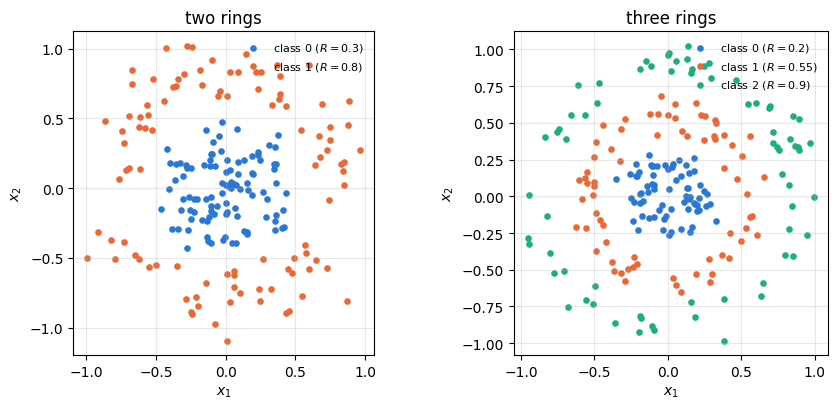

In [4]:
# ==============================================================================
# STEP 1: the two data sets and the random train/test splits
# ==============================================================================
def make_rings(key, n_per_class, radii, noise):
    """Points on concentric rings with Gaussian radial noise; label c for ring c.

    MATH   theta ~ U[0, 2 pi),  r = R_c + noise * xi  with xi ~ N(0, 1),  x = (r cos theta, r sin theta).
    Returns X of shape (n_classes * n_per_class, 2) and integer labels of the same length (class blocks in order).
    """
    keys = jax.random.split(key, 2 * len(radii))
    X, y = [], []
    for c, R in enumerate(radii):
        theta = 2 * jnp.pi * jax.random.uniform(keys[2 * c], (n_per_class,), dtype=RDTYPE)
        r = R + noise * jax.random.normal(keys[2 * c + 1], (n_per_class,), dtype=RDTYPE)
        X.append(jnp.stack([r * jnp.cos(theta), r * jnp.sin(theta)], axis=1))
        y.append(np.full(n_per_class, c))
    return jnp.concatenate(X), np.concatenate(y)


def random_splits(key, M, n_train, n_splits):
    """`n_splits` random train/test splits of M points; split k uses its own key jax.random.split(key, n_splits)[k].

    Returns two int arrays of shapes (n_splits, n_train) and (n_splits, M - n_train).
    JAX   jax.vmap over the keys draws all permutations in one call.
    """
    keys = jax.random.split(key, n_splits)
    perms = np.asarray(jax.vmap(lambda k: jax.random.permutation(k, M))(keys))
    return perms[:, :n_train], perms[:, n_train:]


N_SPLITS, TRAIN_FRACTION = 10, 0.6
DATA = {}
for name, key, n_per, radii, noise in [("two rings", 11, 100, (0.3, 0.8), 0.13),
                                        ("three rings", 12, 70, (0.2, 0.55, 0.9), 0.07)]:
    X, y = make_rings(jax.random.PRNGKey(key), n_per, radii, noise)
    M = X.shape[0]
    tr, te = random_splits(jax.random.PRNGKey(100 + key), M, int(TRAIN_FRACTION * M), N_SPLITS)
    DATA[name] = dict(X=X, y=y, n_classes=len(radii), radii=radii, train=tr, test=te)
    r = np.linalg.norm(np.asarray(X), axis=1)
    ranges = ", ".join(f"[{r[y == c].min():.3f}, {r[y == c].max():.3f}]" for c in range(len(radii)))
    print(f"{name:11s}: M = {M} points, {len(radii)} classes, {tr.shape[1]} training / {te.shape[1]} test points "
          f"per split; radii of the classes {ranges}")
assert all(len(set(d["train"][0]) | set(d["test"][0])) == d["X"].shape[0] for d in DATA.values())

CLASS_COLORS = [PALETTE[0], PALETTE[1], PALETTE[2]]
fig, axes = plt.subplots(1, 2, figsize=(9.0, 4.2))
for ax, (name, d) in zip(axes, DATA.items()):
    for c in range(d["n_classes"]):
        Xc = np.asarray(d["X"])[d["y"] == c]
        ax.scatter(Xc[:, 0], Xc[:, 1], s=14, color=CLASS_COLORS[c], label=f"class {c} ($R={d['radii'][c]}$)")
    ax.set_aspect("equal")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_title(name)
    ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()

The radii of the classes do not overlap in these two samples, but the gaps between them are narrow: $0.534$ to
$0.575$ between the two rings, $0.370$ to $0.405$ and $0.698$ to $0.733$ in the three-ring set. The largest
$\vert\mathbf x\vert$ is about one, so the data fill roughly the square $[-1,1]^2$; the encoding of Section 4 turns
coordinates into rotation angles, and the size of the data range matters there.

### 3.2 A feature map that makes the rings linearly separable

The cell evaluates Eq. (3) on the two-ring set both ways, as the scalar product of the explicit feature vectors of
Eq. (1) and as $(\mathbf x\cdot\mathbf x')^2$, and then classifies all points by the plane $\phi_1+\phi_3=r_c^2$ in
feature space with $r_c=0.55$, halfway between the two rings.

max |phi(x).phi(x') - (x.x')^2| over all 40000 pairs: 4.44e-16
plane phi_1 + phi_3 = 0.55^2 classifies 100.0 % of the 200 points correctly


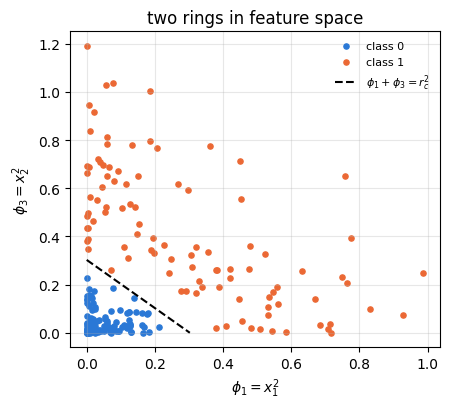

In [5]:
# ==============================================================================
# STEP 2: the kernel trick on Eq. (1), and the rings in feature space
# ==============================================================================
def poly_features(X):
    """Feature map of Eq. (1):  phi(x) = (x1^2, sqrt(2) x1 x2, x2^2)."""
    return jnp.stack([X[:, 0] ** 2, jnp.sqrt(2.0) * X[:, 0] * X[:, 1], X[:, 1] ** 2], axis=1)


X2, y2 = DATA["two rings"]["X"], DATA["two rings"]["y"]
Phi = poly_features(X2)
err_trick = max_abs(Phi @ Phi.T - (X2 @ X2.T) ** 2)
print(f"max |phi(x).phi(x') - (x.x')^2| over all {X2.shape[0] ** 2} pairs: {err_trick:.2e}")
assert err_trick < TOL

r_c = 0.55
pred_plane = np.asarray(Phi[:, 0] + Phi[:, 2] > r_c ** 2).astype(int)        # outer ring above the plane
acc_plane = float(np.mean(pred_plane == y2))
print(f"plane phi_1 + phi_3 = {r_c}^2 classifies {100 * acc_plane:.1f} % of the {len(y2)} points correctly")
assert acc_plane > 0.95

fig, ax = plt.subplots(figsize=(4.6, 4.2))
for c in range(2):
    ax.scatter(np.asarray(Phi[y2 == c, 0]), np.asarray(Phi[y2 == c, 2]), s=14, color=CLASS_COLORS[c],
               label=f"class {c}")
u = np.linspace(0, r_c ** 2, 50)
ax.plot(u, r_c ** 2 - u, "k--", lw=1.5, label=r"$\phi_1+\phi_3=r_c^2$")
ax.set_xlabel(r"$\phi_1=x_1^2$")
ax.set_ylabel(r"$\phi_3=x_2^2$")
ax.set_title("two rings in feature space")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

The two expressions agree to round-off, and in the plane $(\phi_1,\phi_3)$ the rings become two groups separated by a
straight line: the rule $r<0.55$, chosen here by looking at all the data, classifies every point correctly. A learning
algorithm has to find such a rule from the training data alone, which is the job of the SVM.

### 3.3 The support vector machine and its dual problem

Let $\boldsymbol\phi_i=\boldsymbol\phi(\mathbf x_i)$ and $y_i\in\{-1,+1\}$. A plane $\mathbf w\cdot\boldsymbol\phi+b=0$
classifies point $i$ correctly with a safety margin if $y_i(\mathbf w\cdot\boldsymbol\phi_i+b)\geq1$. The distance of
the planes $\mathbf w\cdot\boldsymbol\phi+b=\pm1$ from the decision plane is $1/\vert\mathbf w\vert$, so maximising
this *margin* means minimising $\vert\mathbf w\vert^2$. Overlapping classes cannot satisfy all constraints, and the
*soft-margin* SVM allows violations $\xi_i\geq0$ at a cost $C$ per unit:

$$\min_{\mathbf w,b,\boldsymbol\xi}\ \frac12\vert\mathbf w\vert^2+C\sum_{i=1}^M\xi_i\qquad\text{subject to}\qquad
y_i(\mathbf w\cdot\boldsymbol\phi_i+b)\geq1-\xi_i,\quad \xi_i\geq0 . \tag{6}$$

A large $C$ punishes violations strongly and fits the training data closely; a small $C$ accepts more violations in
exchange for a wider margin. We use $C=10$ throughout. To remove $\mathbf w$, which may live in a huge space, we
introduce Lagrange multipliers $\alpha_i\geq0$ for the margin constraints and $\mu_i\geq0$ for $\xi_i\geq0$,

$$\mathcal L=\frac12\vert\mathbf w\vert^2+C\sum_i\xi_i-\sum_i\alpha_i\big[y_i(\mathbf w\cdot\boldsymbol\phi_i+b)-1+\xi_i\big]-\sum_i\mu_i\xi_i . \tag{7}$$

For fixed multipliers, the minimum of $\mathcal L$ over $\mathbf w,b,\boldsymbol\xi$ is a lower bound on the optimum of
Eq. (6), because at any feasible point the subtracted terms are non-negative (*weak duality*). The dual problem
maximises this bound over the multipliers, and for a convex problem such as Eq. (6) the largest bound equals the
optimum (*strong duality*). At the minimum over the primal variables the derivatives vanish:

$$\begin{aligned}
\frac{\partial\mathcal L}{\partial\mathbf w}&=\mathbf w-\sum_i\alpha_iy_i\boldsymbol\phi_i=0
&&\Rightarrow\quad \mathbf w=\sum_i\alpha_iy_i\boldsymbol\phi_i,\\
\frac{\partial\mathcal L}{\partial b}&=-\sum_i\alpha_iy_i=0 &&\Rightarrow\quad \sum_i\alpha_iy_i=0,\\
\frac{\partial\mathcal L}{\partial\xi_i}&=C-\alpha_i-\mu_i=0 &&\Rightarrow\quad 0\leq\alpha_i\leq C .
\end{aligned} \tag{8}$$

The first line says that the optimal $\mathbf w$ is a combination of the training feature vectors. Substituting the
three conditions back into Eq. (7), the terms with $b$ and $\xi_i$ cancel, and
$\frac12\vert\mathbf w\vert^2-\sum_i\alpha_iy_i\mathbf w\cdot\boldsymbol\phi_i=-\frac12\vert\mathbf w\vert^2$ leaves
the **dual problem**

$$\max_{\boldsymbol\alpha}\ D(\boldsymbol\alpha)=\sum_i\alpha_i-\frac12\sum_{i,j}\alpha_i\alpha_jy_iy_jK_{ij}
\qquad\text{subject to}\qquad 0\leq\alpha_i\leq C,\quad\sum_i\alpha_iy_i=0, \tag{9}$$

with $K_{ij}=\boldsymbol\phi_i\cdot\boldsymbol\phi_j=k(\mathbf x_i,\mathbf x_j)$. In matrix form
$D=\mathbf 1\cdot\boldsymbol\alpha-\frac12\boldsymbol\alpha^{\rm T}Q\boldsymbol\alpha$ with
$Q_{ij}=y_iy_jK_{ij}$. The feature vectors have disappeared; the kernel matrix is all the training needs.

The optimality (Karush–Kuhn–Tucker) conditions classify the training points. Points with $\alpha_i=0$ lie on or
outside the margin, $y_i(\mathbf w\cdot\boldsymbol\phi_i+b)\geq1$, and do not enter $\mathbf w$; points with
$0<\alpha_i<C$ lie exactly on the margin, $y_i(\mathbf w\cdot\boldsymbol\phi_i+b)=1$; points with $\alpha_i=C$ have
$y_i(\mathbf w\cdot\boldsymbol\phi_i+b)\leq1$ and in general violate it. The points with $\alpha_i>0$ are the
**support vectors**. Each margin point determines the offset,

$$b=y_i-\sum_j\alpha_jy_jK_{ji}\qquad\text{for any } i \text{ with } 0<\alpha_i<C, \tag{10}$$

and we average Eq. (10) over all such points to reduce round-off. Two numbers certify a solution. The primal
objective of Eq. (6), evaluated with $\mathbf w$ from Eq. (8) and the smallest admissible slacks
$\xi_i=\max(0,1-y_if(\mathbf x_i))$, is

$$P=\frac12\boldsymbol\alpha^{\rm T}Q\boldsymbol\alpha+C\sum_i\max\big(0,\,1-y_if(\mathbf x_i)\big), \tag{11}$$

and weak duality guarantees $P\geq D$ for any feasible $\boldsymbol\alpha$, with equality only at the optimum. The
relative *duality gap* $(P-D)/P$ therefore measures the distance from the solution without knowing it. A new point is
classified by the sign of the **decision function**

$$f(\mathbf x)=\mathbf w\cdot\boldsymbol\phi(\mathbf x)+b=\sum_i\alpha_iy_i\,k(\mathbf x_i,\mathbf x)+b , \tag{12}$$

which again needs only kernel values, now between the new point and the training points.

### 3.4 Solving the dual problem by accelerated projected gradient ascent

For a positive semidefinite kernel (Section 3.5), Eq. (9) maximises a concave quadratic function over a convex set,
the box $[0,C]^M$ intersected with the hyperplane $\mathbf y\cdot\boldsymbol\alpha=0$. Projected gradient ascent takes
a step along the gradient $\nabla D=\mathbf 1-Q\boldsymbol\alpha$ and returns to the set by the Euclidean projection
$\Pi$,

$$\boldsymbol\alpha\leftarrow\Pi\big(\boldsymbol\alpha+\eta\,(\mathbf 1-Q\boldsymbol\alpha)\big),\qquad \eta=1/\lambda_{\max}(Q), \tag{13}$$

where the step $\eta$ is the inverse of the largest curvature of $D$. The accelerated version (FISTA, Beck and
Teboulle, 2009) applies the same step at an extrapolated point
$\mathbf z_t=\boldsymbol\alpha_t+\frac{\tau_t-1}{\tau_{t+1}}(\boldsymbol\alpha_t-\boldsymbol\alpha_{t-1})$, with
$\tau_1=1$ and $\tau_{t+1}=\frac12\big(1+\sqrt{1+4\tau_t^2}\big)$, which reduces the error of $D$ after $n$ steps from
$O(1/n)$ to $O(1/n^2)$.

The projection has a closed form up to one number. Minimising $\frac12\vert\boldsymbol\alpha-\mathbf v\vert^2$ over the
box with a multiplier $\mu$ for the hyperplane gives, coordinate by coordinate,

$$\alpha_i(\mu)=\mathrm{clip}\big(v_i-\mu y_i,\ 0,\ C\big),\qquad h(\mu)=\sum_iy_i\,\alpha_i(\mu)=0 . \tag{14}$$

Because $y_i^2=1$, every term $y_i\alpha_i(\mu)$ is a non-increasing function of $\mu$, so $h$ is non-increasing; at
$\mu=\pm(\max_i\vert v_i\vert+C)$ it has opposite signs, and bisection finds its root to machine precision in about
50 halvings.

> **JAX practice.** The iteration of Eq. (13) is a `lax.scan` over a fixed number of steps, and the bisection inside
> the projection is another `lax.scan`, so the whole solver compiles into one XLA program. Wrapping it in `jax.vmap`
> solves many SVMs, for different splits, bandwidths or classes, in one call; Sections 6, 7 and 9 rely on this.

The cell implements the solver, runs it on the two-ring training set of the first split with the polynomial kernel
of Eq. (3), and checks the solution in three ways: the constraints, the duality gap, and, if the library
`scikit-learn` is installed, a comparison with its SVM, which solves the same Eq. (9) by a different method
(sequential minimal optimisation).

In [6]:
# ==============================================================================
# STEP 3: the SVM dual problem, Eq. (9), by FISTA with the exact projection of Eq. (14)
# ==============================================================================
C_SVM = 10.0          # cost of a margin violation, Eq. (6), the same for every kernel
N_ITER = 600          # FISTA iterations for the many SVMs of Sections 6, 7, 9 (checked below against 4000)


def project_box_hyperplane(v, y, C, n_bisect=50):
    """Euclidean projection of v onto {a : 0 <= a_i <= C, sum_i y_i a_i = 0}, Eq. (14).

    MATH   a_i(mu) = clip(v_i - mu y_i, 0, C);  h(mu) = sum_i y_i a_i(mu) is non-increasing in mu (y_i^2 = 1),
           h(-B) >= 0 >= h(B) for B = max|v| + C;  bisection on mu for the root of h.
    JAX    the bisection is a lax.scan with a fixed number of halvings (no Python loop, no data-dependent exit).
    """
    B = jnp.max(jnp.abs(v)) + C

    def halve(bounds, _):
        lo, hi = bounds
        mu = 0.5 * (lo + hi)
        h = jnp.dot(y, jnp.clip(v - mu * y, 0.0, C))
        return (jnp.where(h > 0, mu, lo), jnp.where(h > 0, hi, mu)), None

    (lo, hi), _ = lax.scan(halve, (-B, B), None, length=n_bisect)
    return jnp.clip(v - 0.5 * (lo + hi) * y, 0.0, C)


@partial(jax.jit, static_argnames=("n_iter",))
def svm_dual_solve(K, y, C, n_iter=N_ITER, a0=None):
    """Soft-margin SVM: maximise D(a) = sum a - a^T Q a / 2, Q = (y y^T) * K, over 0 <= a <= C, y.a = 0  (Eq. 9).

    MATH   FISTA:  a_{t+1} = Proj(z_t + eta (1 - Q z_t)),  eta = 1 / lambda_max(Q),
                   z_{t+1} = a_{t+1} + (t_k - 1)/t_{k+1} (a_{t+1} - a_t),  t_{k+1} = (1 + sqrt(1 + 4 t_k^2)) / 2.
           offset b from Eq. (10), averaged over the margin points 0 < a_i < C.
    COST   O(M^2) per iteration (one matrix-vector product) + O(M n_bisect) for the projection.
    Returns (alpha, b).  `a0` (optional) is a feasible starting point.
    """
    Q = (y[:, None] * y[None, :]) * K
    eta = 1.0 / jnp.linalg.eigvalsh(Q)[-1]

    def step(carry, _):
        a, z, t = carry
        a_new = project_box_hyperplane(z + eta * (1.0 - Q @ z), y, C)
        t_new = 0.5 * (1.0 + jnp.sqrt(1.0 + 4.0 * t * t))
        return (a_new, a_new + (t - 1.0) / t_new * (a_new - a), t_new), None

    a0 = jnp.zeros_like(y) if a0 is None else a0                  # default start: alpha = 0 (feasible)
    (alpha, _, _), _ = lax.scan(step, (a0, a0, jnp.asarray(1.0, dtype=y.dtype)), None, length=n_iter)
    g = y - K @ (alpha * y)                                         # y_i - sum_j a_j y_j K_ji, Eq. (10)
    on_margin = (alpha > 1e-6 * C) & (alpha < (1.0 - 1e-6) * C)
    support = alpha > 1e-6 * C
    b = jnp.where(jnp.any(on_margin),
                  jnp.sum(jnp.where(on_margin, g, 0.0)) / jnp.maximum(jnp.sum(on_margin), 1),
                  jnp.sum(jnp.where(support, g, 0.0)) / jnp.maximum(jnp.sum(support), 1))
    return alpha, b


def svm_decision(alpha, b, y, K_new_train):
    """Decision function of Eq. (12) for new points:  f = K_new_train @ (alpha * y) + b."""
    return K_new_train @ (alpha * y) + b


def svm_duality_gap(K, y, alpha, b, C):
    """Primal P of Eq. (11) and dual D of Eq. (9); returns (P, D). P >= D, with equality at the optimum."""
    Q = (y[:, None] * y[None, :]) * K
    quad = alpha @ Q @ alpha
    f = svm_decision(alpha, b, y, K)
    return 0.5 * quad + C * jnp.sum(jnp.maximum(0.0, 1.0 - y * f)), jnp.sum(alpha) - 0.5 * quad


tr0, te0 = DATA["two rings"]["train"][0], DATA["two rings"]["test"][0]
Xtr, Xte = X2[tr0], X2[te0]
ytr, yte = jnp.where(y2[tr0] == 1, 1.0, -1.0), jnp.where(y2[te0] == 1, 1.0, -1.0)
K_poly_tr, K_poly_te = (Xtr @ Xtr.T) ** 2, (Xte @ Xtr.T) ** 2

for n_iter in (N_ITER, 4000):
    alpha, b = svm_dual_solve(K_poly_tr, ytr, C_SVM, n_iter=n_iter)
    P, D = svm_duality_gap(K_poly_tr, ytr, alpha, b, C_SVM)
    f_te = svm_decision(alpha, b, ytr, K_poly_te)
    acc_te = float(jnp.mean(jnp.sign(f_te) == yte))
    acc_tr = float(jnp.mean(jnp.sign(svm_decision(alpha, b, ytr, K_poly_tr)) == ytr))
    print(f"{n_iter:5d} iterations: D = {float(D):.6f}, P = {float(P):.6f}, gap (P-D)/P = {float((P - D) / P):.1e}; "
          f"|y.alpha| = {abs(float(alpha @ ytr)):.1e}, {int(jnp.sum(alpha > 1e-6 * C_SVM))} support vectors; "
          f"train {100 * acc_tr:.1f} %, test {100 * acc_te:.1f} %")
assert float(jnp.min(alpha)) >= 0.0 and float(jnp.max(alpha)) <= C_SVM and abs(float(alpha @ ytr)) < 1e-8
assert float((P - D) / P) < 1e-6
alpha_ref, b_ref, f_ref = alpha, b, f_te

try:
    from sklearn.svm import SVC
    clf = SVC(kernel="precomputed", C=C_SVM, tol=1e-8).fit(np.asarray(K_poly_tr), np.asarray(ytr))
    f_sk = clf.decision_function(np.asarray(K_poly_te))
    print(f"scikit-learn SVC on the same kernel: b = {clf.intercept_[0]:.6f} (ours {float(b_ref):.6f}), "
          f"max |f - f_sklearn| on the test points = {np.max(np.abs(np.asarray(f_ref) - f_sk)):.1e}")
    assert np.max(np.abs(np.asarray(f_ref) - f_sk)) < 1e-3
except ImportError:
    print("scikit-learn not installed: the duality gap above is the certificate of the solution")

  600 iterations: D = 91.157414, P = 91.207698, gap (P-D)/P = 5.5e-04; |y.alpha| = 6.0e-14, 17 support vectors; train 100.0 %, test 100.0 %
 4000 iterations: D = 91.157467, P = 91.157467, gap (P-D)/P = 9.2e-11; |y.alpha| = 5.3e-14, 16 support vectors; train 100.0 %, test 100.0 %


scikit-learn SVC on the same kernel: b = -2.292358 (ours -2.292358), max |f - f_sklearn| on the test points = 3.9e-07


After 4000 iterations the relative duality gap is $9\times10^{-11}$ and the constraint
$\mathbf y\cdot\boldsymbol\alpha=0$ holds to round-off; scikit-learn, installed on the machine that executed this
notebook, gives the same offset $b$ and decision values that agree with ours to $4\times10^{-7}$. With 600 iterations
the gap is $5.5\times10^{-4}$ and the predicted labels are the same. The many SVMs of Sections 6, 7 and 9 use this cheaper
setting, and Section 5 uses 4000 iterations. With the kernel of Eq. (3) the SVM classifies all training and test
points of this split correctly, and only 16 of the 120 training points are support vectors and enter the decision
function.

### 3.5 Valid kernels are positive semidefinite

A function $k$ is the scalar product of some feature map only if every kernel matrix it produces is **positive
semidefinite** (PSD), $\mathbf c^{\rm T}K\mathbf c\geq0$ for every real vector $\mathbf c$. The necessity is one line,

$$\mathbf c^{\rm T}K\mathbf c=\sum_{i,j}c_ic_j\,\boldsymbol\phi_i\cdot\boldsymbol\phi_j=\Big\vert\sum_ic_i\boldsymbol\phi_i\Big\vert^2\geq0 , \tag{15}$$

and the converse also holds: a symmetric function all of whose kernel matrices are PSD is the scalar product of some
feature map (the Moore–Aronszajn theorem; Mercer's theorem gives an explicit construction for continuous kernels;
Schölkopf and Smola, 2002). For the SVM the property is essential: with
$Q=\mathrm{diag}(\mathbf y)\,K\,\mathrm{diag}(\mathbf y)$ the function $D$ of Eq. (9) is concave exactly when $K$ is
PSD, and only then is every local maximum a global one, so that projected gradient ascent is guaranteed to reach the
optimal value. The maximiser $\boldsymbol\alpha$ itself need not be unique: the polynomial kernel of Eq. (3) has rank
three, and different $\boldsymbol\alpha$ can give the same $\mathbf w$ and the same decision function. The cell checks the
smallest eigenvalue of three candidates on the two-ring set: the polynomial kernel of Eq. (3), the Gaussian kernel,
and the "sigmoid kernel" $\tanh(2\,\mathbf x\cdot\mathbf x'-1)$, a function borrowed from neural networks that is
often used as a kernel although it is not PSD for most values of its parameters. It then trains the SVM with the sigmoid matrix from four different
feasible starting points and compares the solutions.

In [7]:
# ==============================================================================
# STEP 4: positive semidefiniteness of three candidate kernels (wrong control included)
# ==============================================================================
def rbf_kernel(XA, XB, gamma):
    """Gaussian (RBF) kernel  k(x, x') = exp(-gamma |x - x'|^2)."""
    d2 = jnp.sum((XA[:, None, :] - XB[None, :, :]) ** 2, axis=-1)
    return jnp.exp(-gamma * d2)


sigmoid = lambda XA, XB: jnp.tanh(2.0 * XA @ XB.T - 1.0)
candidates = {"(x.x')^2": (X2 @ X2.T) ** 2, "exp(-3|x-x'|^2)": rbf_kernel(X2, X2, 3.0), "tanh(2x.x' - 1)": sigmoid(X2, X2)}
lam_min = {}
for name, Kc in candidates.items():
    lam = np.linalg.eigvalsh(np.asarray(Kc))
    lam_min[name] = lam[0]
    print(f"{name:16s}: smallest eigenvalue {lam[0]:+.3e}, largest {lam[-1]:.3e}, "
          f"{int(np.sum(lam < -1e-8 * lam[-1]))} negative eigenvalues")
assert lam_min["(x.x')^2"] > -TOL * 1e3 and lam_min["exp(-3|x-x'|^2)"] > -TOL * 1e3
assert lam_min["tanh(2x.x' - 1)"] < -1.0

# wrong control in the SVM: the non-PSD matrix, solved from four different feasible starting points
K_bad, K_bad_te = sigmoid(Xtr, Xtr), sigmoid(Xte, Xtr)
sols = []
for k in range(4):
    a_start = None if k == 0 else project_box_hyperplane(
        C_SVM * jax.random.uniform(jax.random.PRNGKey(40 + k), ytr.shape, dtype=RDTYPE), ytr, C_SVM)
    a_k, b_k = svm_dual_solve(K_bad, ytr, C_SVM, n_iter=4000, a0=a_start)
    sols.append((a_k, b_k))
spread = max(max_abs(a_k - sols[0][0]) for a_k, _ in sols)
a_bad, b_bad = sols[0]
a_np, y_np = np.asarray(a_bad), np.asarray(ytr)
sv = a_np > 1e-6 * C_SVM
free = sv & (a_np < (1.0 - 1e-6) * C_SVM)                                # 0 < alpha_i < C
Q_free = (y_np[:, None] * y_np[None, :] * np.asarray(K_bad))[np.ix_(free, free)]
B_tan = np.linalg.svd(y_np[free][None, :])[2][1:].T                      # orthonormal basis of {u : y_free . u = 0}
lam_free = np.linalg.eigvalsh(Q_free)[0]
lam_tan = np.linalg.eigvalsh(B_tan.T @ Q_free @ B_tan)[0]
grad = 1.0 - (y_np[:, None] * y_np[None, :] * np.asarray(K_bad)) @ a_np          # gradient of D
nu = np.mean(grad[free] * y_np[free])                                    # multiplier of y.alpha = 0
red = grad - nu * y_np                                                   # reduced gradient: 0 free, <= 0 at 0, >= 0 at C
acc_bad = float(jnp.mean(jnp.sign(svm_decision(a_bad, b_bad, ytr, K_bad_te)) == yte))
print(f"SVM with tanh(2x.x' - 1): lambda_min on the training set {np.linalg.eigvalsh(np.asarray(K_bad))[0]:+.2f}; "
      f"max |alpha - alpha_0| over 4 starts = {spread:.1e}; test accuracy {100 * acc_bad:.1f} %")
print(f"   {int(sv.sum())} support vectors, {int(sv.sum() - free.sum())} at alpha = C and {int(free.sum())} free; "
      f"lambda_min of Q on the free coordinates {lam_free:+.2f}, on the free coordinates with y.u = 0 {lam_tan:+.3f}")
print(f"   reduced gradient: max |.| on the free coordinates {np.max(np.abs(red[free])):.1e}, "
      f"max at alpha = 0 {np.max(red[~sv]):+.3f}, min at alpha = C {np.min(red[sv & ~free]):+.3f}")

(x.x')^2        : smallest eigenvalue -6.612e-15, largest 3.017e+01, 0 negative eigenvalues
exp(-3|x-x'|^2) : smallest eigenvalue -2.841e-15, largest 6.898e+01, 0 negative eigenvalues
tanh(2x.x' - 1) : smallest eigenvalue -1.361e+02, largest 4.402e+01, 51 negative eigenvalues


SVM with tanh(2x.x' - 1): lambda_min on the training set -81.51; max |alpha - alpha_0| over 4 starts = 7.1e-04; test accuracy 100.0 %
   16 support vectors, 10 at alpha = C and 6 free; lambda_min of Q on the free coordinates -3.92, on the free coordinates with y.u = 0 +0.028
   reduced gradient: max |.| on the free coordinates 8.6e-06, max at alpha = 0 -0.010, min at alpha = C +0.082


The polynomial and Gaussian kernels have no negative eigenvalues beyond round-off; the sigmoid matrix has 51 negative
eigenvalues out of 200, the smallest $-136$, so it is not the scalar product of any feature map. Without positivity
$D$ is not concave and the SVM loses the guarantee that a maximum it finds is the global one. On these data the loss
does not show in the result: the four runs end at the same $\boldsymbol\alpha$ to $7\times10^{-4}$ and the classifier
is correct on all test points. The end point has 16 support vectors, 10 of them at the bound $\alpha_i=C$ and 6 free.
On the free coordinates $Q$ still has a negative eigenvalue, $-3.9$, but along the directions that keep
$\mathbf y\cdot\boldsymbol\alpha=0$ its smallest eigenvalue is $+0.03$, the reduced gradient vanishes on the free
coordinates and points out of the box at both bounds. These are the conditions of a local maximum; nothing certifies
that it is the global one. A non-PSD matrix is detected by its eigenvalues, the check that this cell makes; Section 9
meets the problem again, because a kernel matrix estimated from finitely many shots is not exactly PSD.

### 3.6 More than two classes

For the three-ring set we use the *one-versus-rest* construction: one SVM per class $c$ with labels $y_i=+1$ for class
$c$ and $-1$ for all others, and the label of a new point is the class whose decision function $f_c(\mathbf x)$ is
largest. The $n_{\rm c}$ problems share the kernel matrix and differ only in $\mathbf y$, so they are solved in one
`vmap` call. The next cell packs this, together with batching over splits, into two functions used for the rest of the
notebook: `fit_and_score` trains and tests a batch of splits with given kernel matrices, and `tune_and_score` chooses
the bandwidth of a kernel for every split by holding out one third of the training points.

In [8]:
# ==============================================================================
# STEP 5: batched training and testing (splits x classes), and bandwidth tuning on held-out data
# ==============================================================================
@partial(jax.jit, static_argnames=("n_iter",))
def svm_solve_batch(K_batch, Y_batch, C, n_iter=N_ITER):
    """jax.vmap of svm_dual_solve over a batch of (kernel matrix, targets): (B, m, m), (B, m) -> (B, m), (B,)."""
    return jax.vmap(lambda K, y: svm_dual_solve(K, y, C, n_iter=n_iter))(K_batch, Y_batch)


def ovr_targets(labels, n_classes):
    """+-1 targets: one problem (class 1 versus class 0) for two classes, one per class (one versus rest) otherwise."""
    labels = np.asarray(labels)
    if n_classes == 2:
        return np.where(labels == 1, 1.0, -1.0)[None]
    return np.stack([np.where(labels == c, 1.0, -1.0) for c in range(n_classes)])


def predict_from_decisions(F):
    """F of shape (n_problems, ..., m): label 1 if f > 0 for one problem, the arg-max over problems otherwise."""
    return (F[0] > 0).astype(int) if F.shape[0] == 1 else np.argmax(F, axis=0)


def fit_and_score(K_full, labels, train_idx, test_idx, n_classes, C=C_SVM, n_iter=N_ITER):
    """Train on every split and return (test accuracies, train accuracies), each of shape (S,).

    K_full     (M, M) kernel matrix of all points, or (S, M, M), one per split
    train_idx  (S, m_tr) and test_idx (S, m_te) integer index arrays
    All S * n_problems SVMs are solved in one batched call.
    """
    K_full = np.asarray(K_full)
    S = train_idx.shape[0]
    if K_full.ndim == 2:
        K_full = np.broadcast_to(K_full, (S,) + K_full.shape)
    K_tr = np.stack([K_full[s][np.ix_(train_idx[s], train_idx[s])] for s in range(S)])
    K_te = np.stack([K_full[s][np.ix_(test_idx[s], train_idx[s])] for s in range(S)])
    Y = np.stack([ovr_targets(labels[train_idx[s]], n_classes) for s in range(S)])       # (S, P, m_tr)
    P = Y.shape[1]
    alpha, b = svm_solve_batch(jnp.asarray(np.repeat(K_tr, P, axis=0)), jnp.asarray(Y.reshape(S * P, -1)), C,
                               n_iter=n_iter)
    ay = (np.asarray(alpha) * Y.reshape(S * P, -1)).reshape(S, P, -1)
    b = np.asarray(b).reshape(S, P, 1)
    F_te = np.einsum("sij,spj->psi", K_te, ay) + np.moveaxis(b, 1, 0)                     # (P, S, m_te)
    F_tr = np.einsum("sij,spj->psi", K_tr, ay) + np.moveaxis(b, 1, 0)
    acc_te = np.mean(predict_from_decisions(F_te) == labels[test_idx], axis=1)
    acc_tr = np.mean(predict_from_decisions(F_tr) == labels[train_idx], axis=1)
    return acc_te, acc_tr


def tune_and_score(kernels, labels, train_idx, test_idx, n_classes, C=C_SVM):
    """Bandwidth chosen per split on held-out training data, then test accuracy.

    kernels    (G, M, M): the kernel matrix of all points for G candidate bandwidths (smoothest first)
    For each split the first 2/3 of the (randomly ordered) training points are used to fit every candidate and the
    last 1/3 to validate it; the best candidate (the smoothest one among ties) is refitted on all training points and
    scored on the test points, which play no role in the choice.  Returns (test accuracies (S,), chosen indices (S,)).
    """
    G, S = kernels.shape[0], train_idx.shape[0]
    n_fit = (2 * train_idx.shape[1]) // 3
    fit_idx, val_idx = train_idx[:, :n_fit], train_idx[:, n_fit:]
    K_rep = np.broadcast_to(np.asarray(kernels)[None], (S,) + kernels.shape).reshape((S * G,) + kernels.shape[1:])
    acc_val, _ = fit_and_score(K_rep, labels, np.repeat(fit_idx, G, axis=0), np.repeat(val_idx, G, axis=0),
                               n_classes, C)
    best = np.argmax(acc_val.reshape(S, G), axis=1)
    acc_te, _ = fit_and_score(np.asarray(kernels)[best], labels, train_idx, test_idx, n_classes, C)
    return acc_te, best


# check: the batched path reproduces the single SVM of STEP 3 (polynomial kernel, first split)
K_poly_all = np.asarray((X2 @ X2.T) ** 2)
acc_batch, _ = fit_and_score(K_poly_all, y2, tr0[None], te0[None], 2, n_iter=4000)
acc_single = float(jnp.mean(jnp.sign(f_ref) == yte))
print(f"batched path: test accuracy {acc_batch[0]:.4f}; single SVM of STEP 3: {acc_single:.4f}")
assert abs(acc_batch[0] - acc_single) < 1e-12

batched path: test accuracy 1.0000; single SVM of STEP 3: 1.0000


The batched path reproduces the single SVM. Everything needed for classification is now in place, and the remaining
question is where the kernel matrix comes from.

In [9]:
section_timer("4 quantum feature map")

## 4. The quantum feature map

### 4.1 The encoding circuit

The two coordinates of a data point are distributed over the $N$ qubits cyclically: qubit $q$ carries the feature
$\tilde x_q=x_{(q\bmod d)+1}$, so for $d=2$ the even qubits carry $x_1$ and the odd qubits $x_2$. One layer of the
encoding consists of a Hadamard gate on every qubit, a rotation $R_z(2s\tilde x_q)=e^{-is\tilde x_qZ_q}$ on every
qubit, and a two-qubit rotation $R_{ZZ}(2s^2\tilde x_q\tilde x_{q+1})=e^{-is^2\tilde x_q\tilde x_{q+1}Z_qZ_{q+1}}$ on
every neighbouring pair of the open chain,

$$U(\mathbf x)=\big[W(\mathbf x)\,H^{\otimes N}\big]^L,\qquad
W(\mathbf x)=\prod_{q=0}^{N-2}e^{-is^2\tilde x_q\tilde x_{q+1}Z_qZ_{q+1}}\ \prod_{q=0}^{N-1}e^{-is\tilde x_qZ_q} , \tag{16}$$

with $L=2$ layers. The scale $s$ converts coordinates into angles; the coordinates of our data lie within about
$\pm1.2$, so at $s=1$ the single-qubit angles $2s\tilde x_q$ stay within about $\pm2.4$ rad. All gates of $W$ are diagonal in the computational basis, so they
commute and their order does not matter; the Hadamard layers in between make the circuit non-trivial. The structure,
alternating Hadamard layers and diagonal layers with single-feature and pair-product phases, follows the circuits of
Havlíček *et al.* (2019), who used the pair angle $(\pi-x_1)(\pi-x_2)$ instead of $s^2x_1x_2$. The **product
encoding** omits the $R_{ZZ}$ gates; its states have no entanglement, and its kernel factorises over qubits
(Section 4.3). Figure 2 shows the circuit for $N=4$.

![Encoding circuit for N = 4 qubits and L = 2 layers: each layer applies a Hadamard gate on every qubit, Rz(2 s x1) on qubits 0 and 2, Rz(2 s x2) on qubits 1 and 3, and R_ZZ(2 s^2 x1 x2) on the neighbouring pairs (0,1), (1,2) and (2,3); the product encoding omits the R_ZZ gates](figures/quantum_kernel_encoding.svg)\
**Figure 2.** The encoding circuit $U(\mathbf x)$ of Eq. (16) for $N=4$, $d=2$, as implemented in `feature_circuit`:
Hadamard gates, $R_z(2s\tilde x_q)$ with $\tilde x_q=x_1$ on even and $x_2$ on odd qubits, and
$R_{ZZ}(2s^2x_1x_2)$ on the pairs $(0,1),(1,2),(2,3)$, repeated $L=2$ times. The product encoding is the same circuit
without the $R_{ZZ}$ gates. The inverse $U^\dagger(\mathbf x')$ of the inversion test applies the same gates in reverse
order with negated angles.

The implementation applies the gates one by one with `apply_gate` on the rank-$N$ state tensor. The inverse circuit
reverses the order of the gates and negates every angle, since $R_z(\theta)^\dagger=R_z(-\theta)$,
$R_{ZZ}(\theta)^\dagger=R_{ZZ}(-\theta)$ and $H^\dagger=H$.

In [10]:
# ==============================================================================
# STEP 6: the encoding circuit of Eq. (16) and its inverse
# ==============================================================================
def feature_circuit(psi, x, s, L=2, entangle=True, inverse=False):
    """Apply U(x) of Eq. (16), or U(x)^dagger if `inverse`, to the N-qubit state tensor psi.

    MATH   feature of qubit q: xt_q = x[q mod d];  one layer = H on all qubits, then Rz(2 s xt_q) on every qubit,
           then Rzz(2 s^2 xt_q xt_{q+1}) on the pairs (q, q+1), q = 0..N-2 (omitted if not `entangle`);  L layers.
           Inverse: the same gates in reverse order with negated angles.
    COST   L (2N + N - 1) gates of O(2^N) each.
    JAX    N, d (shapes), L, entangle and inverse are static; x and s are traced, so the function can be vmapped
           over data points and differentiated with respect to s.
    """
    N, d = psi.ndim, x.shape[0]
    xt = [x[q % d] for q in range(N)]

    def layer(psi):
        for q in range(N):
            psi = apply_gate(psi, H, [q])
        for q in range(N):
            psi = apply_gate(psi, rz(2 * s * xt[q]), [q])
        if entangle:
            for q in range(N - 1):
                psi = apply_gate(psi, rzz(2 * s * s * xt[q] * xt[q + 1]), [q, q + 1])
        return psi

    def layer_dagger(psi):
        if entangle:
            for q in reversed(range(N - 1)):
                psi = apply_gate(psi, rzz(-2 * s * s * xt[q] * xt[q + 1]), [q, q + 1])
        for q in reversed(range(N)):
            psi = apply_gate(psi, rz(-2 * s * xt[q]), [q])
        for q in reversed(range(N)):
            psi = apply_gate(psi, H, [q])
        return psi

    for _ in range(L):
        psi = layer_dagger(psi) if inverse else layer(psi)
    return psi


@partial(jax.jit, static_argnames=("N", "L", "entangle"))
def feature_states(X, s, N, L=2, entangle=True):
    """Encoded states of all rows of X as flat vectors: (n_points, 2^N).  jax.vmap over the data points."""
    return jax.vmap(lambda x: feature_circuit(zero_state(N), x, s, L, entangle).reshape(-1))(X)


x_a, x_b = X2[0], X2[150]
psi_a = feature_circuit(zero_state(4), x_a, 1.0)
back = feature_circuit(psi_a, x_a, 1.0, inverse=True)
err_inv = max_abs(back - zero_state(4))
print(f"N = 4: norm of U(x)|0> = {float(jnp.linalg.norm(psi_a)):.15f};  max |U(x)^dag U(x)|0> - |0>| = {err_inv:.1e}")
assert err_inv < TOL

N = 4: norm of U(x)|0> = 0.999999999999999;  max |U(x)^dag U(x)|0> - |0>| = 1.1e-15


The circuit preserves the norm and its inverse undoes it to round-off, the first check of any circuit
implementation.

### 4.2 Properties of the fidelity kernel

The fidelity kernel of Eq. (5) has three properties that follow from its definition: $k(\mathbf x,\mathbf x)=1$
because the states are normalised, $0\leq k\leq1$ by the Cauchy–Schwarz inequality, and $k(\mathbf x,\mathbf x')=k(\mathbf x',\mathbf x)$
because $\vert\langle a\vert b\rangle\vert=\vert\langle b\vert a\rangle\vert$. It is also positive semidefinite. Write
$G_{ij}=\langle\phi_i\vert\phi_j\rangle$ for the matrix of overlaps (the Gram matrix), so that $K_{ij}=G_{ij}\,\overline{G_{ij}}$
is the entry-wise product of $G$ and its complex conjugate, two PSD matrices. The Schur product theorem states that
such a product is PSD; here the proof takes one line, because for real $c_i$

$$\mathbf c^{\rm T}K\mathbf c=\sum_{i,j}c_ic_jG_{ij}\overline{G_{ij}}=\sum_{i,j}c_ic_j\langle\phi_i\vert\phi_j\rangle\langle\phi_j\vert\phi_i\rangle
=\langle\Phi_{\mathbf c}\vert\Phi_{\mathbf c}\rangle\geq0,\qquad
\vert\Phi_{\mathbf c}\rangle=\sum_jc_j\vert\phi_j\rangle\otimes\vert\bar\phi_j\rangle , \tag{17}$$

where $\vert\bar\phi\rangle$ has the complex-conjugate amplitudes. The fidelity kernel is therefore the ordinary scalar
product of the feature vectors $\vert\phi\rangle\otimes\vert\bar\phi\rangle$, equivalently of the density matrices,
$k(\mathbf x,\mathbf x')=\mathrm{Tr}\big[\rho(\mathbf x)\rho(\mathbf x')\big]$ with $\rho=\vert\phi\rangle\langle\phi\vert$.
The modulus $\vert\langle\phi\vert\phi'\rangle\vert$ without the square has no such representation, and the cell
shows that it is not PSD on our data.

The cell computes the kernel matrix of the two-ring set for $N=6$ and $s=1$ in two ways. The *device* way runs the
inversion test, the circuit $U^\dagger(\mathbf x')U(\mathbf x)$ on $\vert0\rangle$, for every pair and reads the
probability of $0\cdots0$ from the final state; a double `vmap` evaluates the $100\times100$ circuits for every second
point in one call.
The *simulator* way prepares the $M$ states once and forms all overlaps by one matrix product,
$K=\vert\Phi^*\Phi^{\rm T}\vert^2$ with the states as rows of $\Phi$, which costs $M$ circuits instead of $M^2$. This
shortcut is not available on hardware, where amplitudes cannot be read out, and is used for the rest of the notebook
once the two agree.

In [11]:
# ==============================================================================
# STEP 7: the kernel matrix by the inversion test (vmap over pairs) and by the state shortcut
# ==============================================================================
@partial(jax.jit, static_argnames=("N", "L", "entangle"))
def inversion_test_p0(XA, XB, s, N, L=2, entangle=True):
    """P(0...0) after U(x')^dag U(x)|0> for all pairs (x in XA, x' in XB): the kernel of Eq. (5), shape (|XA|, |XB|).

    JAX    nested jax.vmap: the inner one over x' in XB, the outer one over x in XA.
    COST   |XA| |XB| circuits of 2 L (3N - 1) gates.
    """
    def p0(x, xp):
        psi = feature_circuit(zero_state(N), x, s, L, entangle)
        psi = feature_circuit(psi, xp, s, L, entangle, inverse=True)
        return jnp.abs(psi[(0,) * N]) ** 2

    return jax.vmap(lambda x: jax.vmap(lambda xp: p0(x, xp))(XB))(XA)


def kernel_from_states(A, B):
    """Fidelity kernel from flat state vectors (rows):  K_ij = |<a_i|b_j>|^2 = |(A^* B^T)_ij|^2."""
    return jnp.abs(jnp.conj(A) @ B.T) ** 2


def quantum_kernel(XA, XB, s, N, L=2, entangle=True):
    """Fidelity kernel matrix between the rows of XA and XB from M_A + M_B prepared states."""
    return kernel_from_states(feature_states(XA, s, N, L, entangle), feature_states(XB, s, N, L, entangle))


N_MAIN, S_MAIN = 6, 1.0
t0 = time.perf_counter()
X_sub = X2[::2]                                                          # every second point: 100 x 100 pairs
K_device = jax.block_until_ready(inversion_test_p0(X_sub, X_sub, S_MAIN, N_MAIN))
t_device = time.perf_counter() - t0
t0 = time.perf_counter()
K_sim = jax.block_until_ready(quantum_kernel(X2, X2, S_MAIN, N_MAIN))
t_sim = time.perf_counter() - t0
err_k = max_abs(K_device - K_sim[::2, ::2])
print(f"N = {N_MAIN}, s = {S_MAIN}: {X_sub.shape[0] ** 2} inversion-test circuits in {t_device:.2f} s, "
      f"{X2.shape[0]} states in {t_sim:.2f} s (both including compilation)")
print(f"max |K_inversion - K_states| = {err_k:.1e}")
print(f"diagonal: max |K_ii - 1| = {max_abs(jnp.diag(K_sim) - 1):.1e};  symmetry: max |K - K^T| = {max_abs(K_sim - K_sim.T):.1e};"
      f"  range of entries [{float(K_sim.min()):.2e}, {float(K_sim.max()):.3f}]")
lam_fid = np.linalg.eigvalsh(np.asarray(K_sim))
G_abs = jnp.abs(jnp.conj(feature_states(X2, S_MAIN, N_MAIN)) @ feature_states(X2, S_MAIN, N_MAIN).T)
lam_abs = np.linalg.eigvalsh(np.asarray(G_abs))
print(f"fidelity kernel |<phi|phi'>|^2: smallest eigenvalue {lam_fid[0]:+.1e}")
print(f"modulus |<phi|phi'>| (wrong control): smallest eigenvalue {lam_abs[0]:+.3f}, "
      f"{int(np.sum(lam_abs < -1e-8))} negative eigenvalues of {len(lam_abs)}")
assert err_k < TOL and max_abs(jnp.diag(K_sim) - 1) < TOL and max_abs(K_sim - K_sim.T) < TOL
assert lam_fid[0] > -TOL * 1e3 and lam_abs[0] < -0.05

N = 6, s = 1.0: 10000 inversion-test circuits in 0.52 s, 200 states in 0.31 s (both including compilation)
max |K_inversion - K_states| = 2.7e-15
diagonal: max |K_ii - 1| = 8.4e-15;  symmetry: max |K - K^T| = 0.0e+00;  range of entries [4.87e-06, 1.000]


fidelity kernel |<phi|phi'>|^2: smallest eigenvalue -4.5e-15
modulus |<phi|phi'>| (wrong control): smallest eigenvalue -0.313, 71 negative eigenvalues of 200


The inversion test and the state shortcut give the same matrix to round-off. The fidelity kernel has unit diagonal,
is symmetric and has no negative eigenvalue beyond round-off, as Eq. (17) requires. The modulus of the overlap, the
square root of every entry, has many negative eigenvalues, so it is not a valid kernel even though each of its entries
measures the similarity of two states.

### 4.3 The product encoding in closed form

Without the $R_{ZZ}$ gates the state is a product of single-qubit states, the overlap is a product of single-qubit
overlaps, and the kernel factorises,

$$k_{\rm prod}(\mathbf x,\mathbf x')=\prod_{q=0}^{N-1}\kappa(\tilde x_q,\tilde x_q'), \tag{18}$$

where $\kappa$ is the fidelity kernel of the one-qubit circuit. For $d=2$ and even $N$ this is
$\big[\kappa(x_1,x_1')\,\kappa(x_2,x_2')\big]^{N/2}$: adding qubits raises the kernel to a higher power. For a single
layer, $L=1$, the one-qubit state is
$R_z(2s x)H\vert0\rangle=\big(e^{-isx}\vert0\rangle+e^{isx}\vert1\rangle\big)/\sqrt2$, its overlap with the state for
$x'$ is $\big(e^{is(x-x')}+e^{-is(x-x')}\big)/2=\cos s(x-x')$, and

$$k_{\rm prod}^{(L=1)}(\mathbf x,\mathbf x')=\prod_{q=0}^{N-1}\cos^2 s(\tilde x_q-\tilde x_q')
\approx\exp\Big(-s^2\sum_{q}(\tilde x_q-\tilde x_q')^2\Big)=\exp\Big(-\frac{Ns^2}{d}\,\vert\mathbf x-\mathbf x'\vert^2\Big) , \tag{19}$$

using $\ln\cos^2u=-u^2-u^4/6-\dots$ for small $u$, and, in the last step, that each of the $d$ features appears on
$N/d$ qubits ($N$ a multiple of $d$). The one-layer product encoding is therefore close to a Gaussian kernel with
bandwidth $\gamma_{\rm eff}=Ns^2/d$. This identifies the role of the two encoding parameters: increasing $N$ at fixed
$s$ narrows the kernel as increasing $\gamma$ does, and keeping $Ns^2$ fixed keeps the kernel approximately
unchanged, exactly in the Gaussian limit. Shaydulin
and Wild (2022) identified the data scale as the bandwidth of quantum kernels and showed, on several kernels and data
sets, that it moves the model between underfitting and overfitting and that optimising it counteracts the decay of
kernel values with the number of qubits.
The cell checks Eq. (18) and the first equality of Eq. (19) exactly, and the Gaussian approximation for a small scale.

In [12]:
# ==============================================================================
# STEP 8: the product kernel, Eqs. (18)-(19), against the circuit
# ==============================================================================
K_prod6 = quantum_kernel(X2, X2, S_MAIN, 6, entangle=False)
K_prod2 = quantum_kernel(X2, X2, S_MAIN, 2, entangle=False)
err_factor = max_abs(K_prod6 - K_prod2 ** 3)
print(f"L = 2 product encoding: max |k(N=6) - k(N=2)^3| = {err_factor:.1e}   (Eq. 18)")

D1 = X2[:, None, 0] - X2[None, :, 0]
D2 = X2[:, None, 1] - X2[None, :, 1]
for s_test in (1.0, 0.1):
    K_L1 = quantum_kernel(X2, X2, s_test, 6, L=1, entangle=False)
    K_cos = (jnp.cos(s_test * D1) ** 2 * jnp.cos(s_test * D2) ** 2) ** 3
    K_gauss = rbf_kernel(X2, X2, 6 * s_test ** 2 / 2)
    print(f"L = 1, N = 6, s = {s_test}: max |k - prod cos^2| = {max_abs(K_L1 - K_cos):.1e};  "
          f"max |k - exp(-N s^2 |dx|^2 / 2)| = {max_abs(K_L1 - K_gauss):.3f}")
    assert max_abs(K_L1 - K_cos) < TOL
assert err_factor < TOL and max_abs(K_L1 - K_gauss) < 0.01

L = 2 product encoding: max |k(N=6) - k(N=2)^3| = 6.1e-15   (Eq. 18)
L = 1, N = 6, s = 1.0: max |k - prod cos^2| = 4.0e-15;  max |k - exp(-N s^2 |dx|^2 / 2)| = 0.032
L = 1, N = 6, s = 0.1: max |k - prod cos^2| = 4.9e-15;  max |k - exp(-N s^2 |dx|^2 / 2)| = 0.001


The product kernel at $N=6$ is the cube of the kernel at $N=2$, and the one-layer product kernel equals the product of
$\cos^2$ factors to round-off. The Gaussian approximation needs $s\vert\tilde x_q-\tilde x_q'\vert\ll1$; with
coordinate differences up to about 2 it deviates by up to $0.032$ at $s=1$ and by $0.001$ at $s=0.1$. The entangling
gates spoil the factorisation, and no closed form of this kind is available for the circuit of Eq. (16).

### 4.4 Measuring the kernel: inversion test and swap test

On a device the kernel is a probability and is estimated from $S$ shots. In the inversion test each shot is a
Bernoulli trial with success probability $k$ (outcome $0\cdots0$), so the number of successes is binomially
distributed and the estimate $\hat k=n_0/S$ has

$$\mathrm{Var}\,\hat k_{\rm inv}=\frac{k(1-k)}{S}. \tag{20}$$

The swap test needs both states at once. An ancilla qubit in $\vert0\rangle$ is put into
$(\vert0\rangle+\vert1\rangle)/\sqrt2$ by a Hadamard gate, controls a swap of the two $N$-qubit registers
$\vert a\rangle=\vert\phi(\mathbf x)\rangle$ and $\vert b\rangle=\vert\phi(\mathbf x')\rangle$ (one controlled-SWAP gate
per qubit pair), and receives a second Hadamard gate. The state before the measurement of the ancilla is

$$\frac12\vert0\rangle\big(\vert a\rangle\vert b\rangle+\vert b\rangle\vert a\rangle\big)+\frac12\vert1\rangle\big(\vert a\rangle\vert b\rangle-\vert b\rangle\vert a\rangle\big), \tag{21}$$

and the probability of ancilla $0$ is
$\frac14\big\Vert\vert a\rangle\vert b\rangle+\vert b\rangle\vert a\rangle\big\Vert^2=\frac14\big(2+2\vert\langle a\vert b\rangle\vert^2\big)$,

$$P_{\rm swap}(0)=\frac{1+k}{2},\qquad \hat k_{\rm swap}=2\hat P(0)-1,\qquad
\mathrm{Var}\,\hat k_{\rm swap}=\frac{4P(0)\big(1-P(0)\big)}{S}=\frac{1-k^2}{S} . \tag{22}$$

The swap test needs $2N+1$ qubits and $N$ three-qubit gates, but it does not run the inverse circuit $U^\dagger$, and it
works for states that come from an unknown source. For small kernel values its variance $1/S$ is much
larger than the $k/S$ of the inversion test, so the inversion test is the better choice when $U$ is known. The cell
implements the swap test for $N=3$ and $N=4$ (seven and nine qubits) and checks Eq. (22) to round-off. It then samples
4000 bit strings of the inversion-test circuit with the engine's sampler and compares the fraction of $0\cdots0$
with the binomial statistics of Eq. (20); Section 9 draws the binomial counts directly instead of bit strings.

In [13]:
# ==============================================================================
# STEP 9: the swap test on 2N+1 qubits, and the inversion test sampled shot by shot
# ==============================================================================
CSWAP = jnp.zeros((8, 8), dtype=CDTYPE).at[:4, :4].set(jnp.eye(4, dtype=CDTYPE)).at[4:, 4:].set(SWAP)


def swap_test_p0(a, b):
    """Probability of ancilla outcome 0 in the swap test of two N-qubit states a, b (tensors), Eq. (22).

    Register: axis 0 = ancilla, axes 1..N = copy of a, axes N+1..2N = copy of b  (2N + 1 qubits).
    Circuit: H(anc); CSWAP(anc, 1+q, 1+N+q) for q = 0..N-1; H(anc).  Returns sum over the rest of |psi[0, ...]|^2.
    """
    N = a.ndim
    psi = jnp.zeros((2,) * (2 * N + 1), dtype=CDTYPE).at[0].set(jnp.tensordot(a, b, axes=0))
    psi = apply_gate(psi, H, [0])
    for q in range(N):
        psi = apply_gate(psi, CSWAP, [0, 1 + q, 1 + N + q])
    psi = apply_gate(psi, H, [0])
    return jnp.sum(jnp.abs(psi[0]) ** 2)


for N_sw in (3, 4):
    pairs = [(0, 1), (0, 150), (40, 199)]
    errs = []
    for i, j in pairs:
        a = feature_circuit(zero_state(N_sw), X2[i], S_MAIN)
        b = feature_circuit(zero_state(N_sw), X2[j], S_MAIN)
        k_ij = float(jnp.abs(jnp.vdot(b, a)) ** 2)
        errs.append(abs(float(swap_test_p0(a, b)) - (1 + k_ij) / 2))
    print(f"swap test on {2 * N_sw + 1} qubits: max |P(0) - (1 + k)/2| over {len(pairs)} pairs = {max(errs):.1e}")
    assert max(errs) < TOL

i, j, SHOTS_CHECK = 0, 150, 4000
psi_ij = feature_circuit(feature_circuit(zero_state(N_MAIN), X2[i], S_MAIN), X2[j], S_MAIN, inverse=True)
bits = np.asarray(sample_bitstrings(jax.random.PRNGKey(5), psi_ij, SHOTS_CHECK))
k_hat = float(np.mean(np.all(bits == 0, axis=1)))
k_true = float(K_sim[i, j])
sd_inv = np.sqrt(k_true * (1 - k_true) / SHOTS_CHECK)
print(f"inversion test, pair ({i},{j}), N = {N_MAIN}: k = {k_true:.4f}, estimate from {SHOTS_CHECK} shots = {k_hat:.4f}, "
      f"deviation = {(k_hat - k_true) / sd_inv:+.2f} standard deviations of Eq. (20)")
print(f"standard deviation per {SHOTS_CHECK} shots: inversion test {sd_inv:.4f}, swap test {np.sqrt((1 - k_true ** 2) / SHOTS_CHECK):.4f}")
assert abs(k_hat - k_true) < 4 * sd_inv

swap test on 7 qubits: max |P(0) - (1 + k)/2| over 3 pairs = 2.2e-15


swap test on 9 qubits: max |P(0) - (1 + k)/2| over 3 pairs = 1.9e-15


inversion test, pair (0,150), N = 6: k = 0.1595, estimate from 4000 shots = 0.1688, deviation = +1.60 standard deviations of Eq. (20)
standard deviation per 4000 shots: inversion test 0.0058, swap test 0.0156


The swap test reproduces $(1+k)/2$ to round-off on seven and nine qubits, and the sampled inversion test agrees with
the exact kernel within $1.6$ binomial standard deviations. For this pair, with $k=0.16$, the standard deviation of the
swap-test estimate is $2.7$ times larger, so it needs $(1+k)/k\approx7$ times as many shots for the same precision.

In [14]:
section_timer("5 classification at N = 6")

## 5. Classifying the rings with a six-qubit kernel

This section uses the entangling encoding with $N=6$, $L=2$ and $s=1$, and the training and test sets of the first
split. Section 7 shows that $s=1$ lies in the range of scales that work well.

### 5.1 Kernel matrices sorted by class

When the training points are ordered by class, the kernel matrix splits into blocks: the diagonal blocks contain the
similarities within a class, the off-diagonal blocks those between classes. A kernel suited to the data has larger
entries in the diagonal blocks.

two rings: mean kernel value in block (class a, class b)
   class 0: 0.625  0.156
   class 1: 0.156  0.184
three rings: mean kernel value in block (class a, class b)
   class 0: 0.774  0.370  0.092
   class 1: 0.370  0.362  0.169
   class 2: 0.092  0.169  0.181


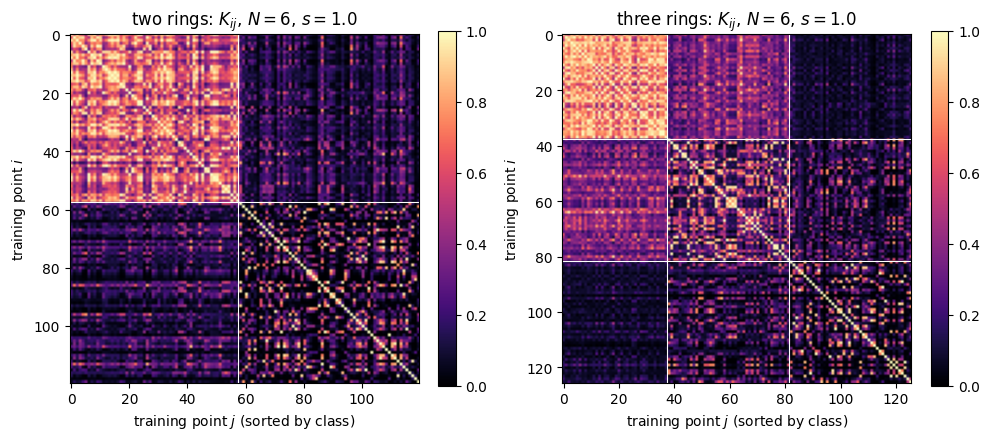

In [15]:
# ==============================================================================
# STEP 10: kernel matrices of the training sets, sorted by class
# ==============================================================================
MAIN = {}
for name, d in DATA.items():
    tr, te = d["train"][0], d["test"][0]
    order = tr[np.argsort(d["y"][tr], kind="stable")]                      # training points sorted by class
    MAIN[name] = dict(order=order, test=te, K=np.asarray(quantum_kernel(d["X"][order], d["X"][order], S_MAIN, N_MAIN)))

fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.4))
for ax, (name, m) in zip(axes, MAIN.items()):
    d = DATA[name]
    im = ax.imshow(m["K"], cmap="magma", vmin=0, vmax=1)
    ax.grid(False)
    counts = np.bincount(d["y"][m["order"]])
    for edge in np.cumsum(counts)[:-1]:
        ax.axhline(edge - 0.5, color="w", lw=0.8)
        ax.axvline(edge - 0.5, color="w", lw=0.8)
    ax.set_title(f"{name}: $K_{{ij}}$, $N={N_MAIN}$, $s={S_MAIN}$")
    ax.set_xlabel("training point $j$ (sorted by class)")
    ax.set_ylabel("training point $i$")
    fig.colorbar(im, ax=ax, fraction=0.046)
    yo = d["y"][m["order"]]
    print(f"{name}: mean kernel value in block (class a, class b)")
    for a in range(d["n_classes"]):
        row = []
        for c in range(d["n_classes"]):
            B = m["K"][np.ix_(yo == a, yo == c)]
            if a == c:
                B = B[~np.eye(B.shape[0], dtype=bool)]                     # exclude the unit diagonal
            row.append(f"{B.mean():.3f}")
        print(f"   class {a}: " + "  ".join(row))
fig.tight_layout()
plt.show()

The block structure is visible, but the blocks are far from orthogonal. Points of the inner ring are similar to each
other (mean kernel value $0.625$), points of the outer ring much less so ($0.184$), and the mean similarity between an
inner and an outer point, $0.156$, is only slightly lower than within the outer ring. The three-ring set shows the
same pattern, with diagonal blocks $0.774$, $0.362$, $0.181$ from the inside out. The asymmetry
between the rings has a simple origin: near the origin all angles of Eq. (16) are small and all states are close to
$U(\mathbf 0)\vert0\rangle$, while on the outer ring the angles vary over a range of about $\pm2.4$ rad and two points
of the same ring can be far apart in Hilbert space. The kernel measures distances between states, which only partly
follow the labels, and the SVM has to make use of the differences that remain.

### 5.2 Kernel principal component analysis

The feature vectors live in a space of dimension $2^{2N}$ (Eq. (17)), but only their projections onto a few
directions can be drawn. Principal component analysis (PCA) chooses the directions of largest variance, and kernel PCA
(Schölkopf, Smola and Müller, 1998) does so using only the kernel matrix. The data are first centred in feature space,
$\tilde{\boldsymbol\phi}_i=\boldsymbol\phi_i-\frac1M\sum_j\boldsymbol\phi_j$, which changes the kernel matrix to

$$\tilde K=JKJ,\qquad J=\mathbb 1-\frac1M\mathbf 1\mathbf 1^{\rm T}. \tag{23}$$

A principal direction $\mathbf u$ of the covariance $\frac1M\sum_i\tilde{\boldsymbol\phi}_i\tilde{\boldsymbol\phi}_i^{\rm T}$
lies in the span of the data, $\mathbf u=\sum_ia_i\tilde{\boldsymbol\phi}_i$. Inserting this into the eigenvalue
equation and taking scalar products with $\tilde{\boldsymbol\phi}_j$ gives $\tilde K^2\mathbf a=M\lambda\,\tilde K\mathbf a$,
which is solved by $\tilde K\mathbf a=M\lambda\,\mathbf a$ (components of $\mathbf a$ in the null space of $\tilde K$ do
not change $\mathbf u$), so the eigenvectors $\mathbf v_k$ of $\tilde K$, with eigenvalues $\tilde\lambda_k$, give the
directions. The
normalisation $\vert\mathbf u\vert^2=\mathbf a^{\rm T}\tilde K\mathbf a=1$ fixes $\mathbf a=\mathbf v_k/\sqrt{\tilde\lambda_k}$,
and the coordinate of point $j$ along $\mathbf u_k$ is

$$z_{jk}=\tilde{\boldsymbol\phi}_j\cdot\mathbf u_k=(\tilde K\mathbf a)_j=\sqrt{\tilde\lambda_k}\,v_{jk} . \tag{24}$$

The fraction $\tilde\lambda_k/\sum_l\tilde\lambda_l$ is the share of the total variance carried by component $k$. The
cell projects the training sets onto the first three components and asks whether the classes can be separated by a
plane in these three coordinates, by training a linear SVM on them and recording its training accuracy.

two rings: variance fractions of the first five components [0.202 0.137 0.113 0.08  0.078]; max |Z Z^T - JKJ| = 2.6e-15;  linear SVM on 3 components: training accuracy 100.0 %


three rings: variance fractions of the first five components [0.196 0.152 0.111 0.082 0.061]; max |Z Z^T - JKJ| = 3.1e-15;  linear SVM on 3 components: training accuracy 96.0 %


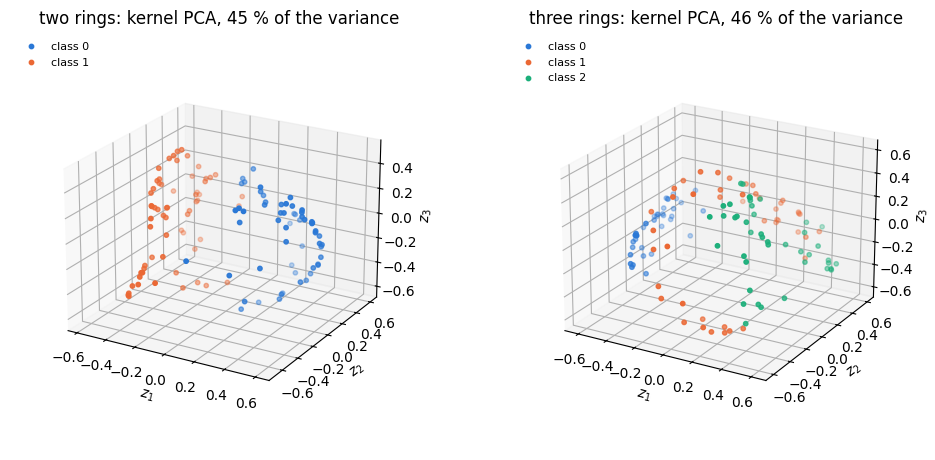

In [16]:
# ==============================================================================
# STEP 11: kernel PCA, Eqs. (23)-(24), and linear separability of the first three components
# ==============================================================================
def kernel_pca(K, n_components=3):
    """Coordinates z_jk = sqrt(lambda_k) v_jk of the centred kernel J K J (Eq. 24) and the variance fractions."""
    M = K.shape[0]
    J = np.eye(M) - np.ones((M, M)) / M
    lam, V = np.linalg.eigh(J @ K @ J)
    lam, V = lam[::-1], V[:, ::-1]                                       # descending
    Z = V[:, :n_components] * np.sqrt(np.maximum(lam[:n_components], 0.0))
    return Z, lam / lam.sum()


fig = plt.figure(figsize=(10.0, 4.6))
for p, (name, m) in enumerate(MAIN.items()):
    d = DATA[name]
    yo = d["y"][m["order"]]
    Z, frac = kernel_pca(m["K"])
    # check of Eq. (24): the scalar products of the projections reproduce the centred kernel along the components
    Zall, _ = kernel_pca(m["K"], n_components=len(yo))
    Mtr = len(yo)
    Jm = np.eye(Mtr) - 1.0 / Mtr
    err_pca = np.max(np.abs(Zall @ Zall.T - Jm @ m["K"] @ Jm))
    K_lin = Z @ Z.T
    acc_sep, _ = fit_and_score(K_lin, yo, np.arange(Mtr)[None], np.arange(Mtr)[None], d["n_classes"],
                               C=1e3, n_iter=4000)
    print(f"{name}: variance fractions of the first five components {np.round(frac[:5], 3)}; "
          f"max |Z Z^T - JKJ| = {err_pca:.1e};  linear SVM on 3 components: training accuracy {100 * acc_sep[0]:.1f} %")
    assert err_pca < TOL * 1e3
    m["acc_sep"] = acc_sep[0]
    ax = fig.add_subplot(1, 2, p + 1, projection="3d")
    for c in range(d["n_classes"]):
        ax.scatter(Z[yo == c, 0], Z[yo == c, 1], Z[yo == c, 2], s=10, color=CLASS_COLORS[c], label=f"class {c}")
    ax.set_xlabel("$z_1$")
    ax.set_ylabel("$z_2$")
    ax.set_zlabel("$z_3$")
    ax.set_title(f"{name}: kernel PCA, {100 * frac[:3].sum():.0f} % of the variance")
    ax.view_init(elev=22, azim=-60)
    ax.set_box_aspect(None, zoom=0.85)                                  # keeps the z label inside the panel
    ax.legend(fontsize=8, loc="upper left")
fig.subplots_adjust(left=0.0, right=0.97, bottom=0.02, top=0.93, wspace=0.05)
plt.show()

The projections reproduce the centred kernel matrix to round-off when all components are kept, which checks Eq. (24).
The first three components carry $45\,\%$ of the variance for the two-ring set and $46\,\%$ for the three-ring set,
so the encoded data are not confined to a few directions. In the projection the two rings form two curved bands on
opposite sides of the cloud, and a plane in the three coordinates separates all training points of the two-ring set.
The three rings overlap partly in this view, and the one-versus-rest planes classify $96\,\%$ of their training
points correctly. The SVM is not restricted to three components and uses the full kernel.

### 5.3 Decision boundaries and accuracies

The SVM is trained on the full kernel matrix of the training set (4000 iterations), and the decision function of
Eq. (12) is evaluated on a $60\times60$ grid of the plane, which needs the kernel between every grid point and every
training point.

two rings: training accuracy 100.0 %, test accuracy 100.0 % (80 test points); support vectors per SVM [20] of 120


three rings: training accuracy 100.0 %, test accuracy 100.0 % (84 test points); support vectors per SVM [11, 33, 21] of 126


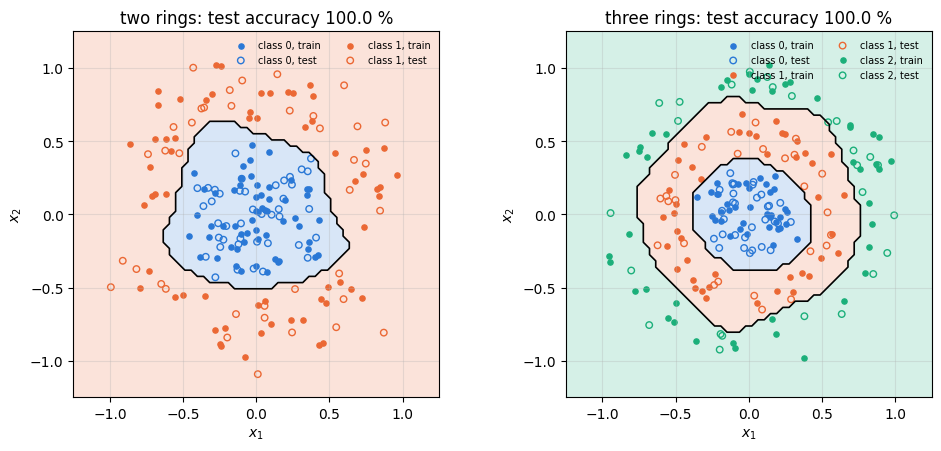

In [17]:
# ==============================================================================
# STEP 12: SVM with the quantum kernel: decision boundaries, train and test accuracy (first split)
# ==============================================================================
from matplotlib.colors import ListedColormap

grid = np.linspace(-1.25, 1.25, 60)
G1, G2 = np.meshgrid(grid, grid)
X_grid = jnp.asarray(np.stack([G1.ravel(), G2.ravel()], axis=1), dtype=RDTYPE)

fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.6))
for ax, (name, m) in zip(axes, MAIN.items()):
    d = DATA[name]
    X_tr, y_tr = d["X"][m["order"]], d["y"][m["order"]]
    X_te, y_te = d["X"][m["test"]], d["y"][m["test"]]
    Y = ovr_targets(y_tr, d["n_classes"])
    alphas, bs = svm_solve_batch(jnp.asarray(np.repeat(m["K"][None], Y.shape[0], 0)), jnp.asarray(Y), C_SVM,
                                 n_iter=4000)
    states_tr = feature_states(X_tr, S_MAIN, N_MAIN)
    decide = lambda XN: np.stack([svm_decision(alphas[p], bs[p], Y[p],
                                               kernel_from_states(feature_states(XN, S_MAIN, N_MAIN), states_tr))
                                  for p in range(Y.shape[0])])
    acc_tr = np.mean(predict_from_decisions(decide(X_tr)) == y_tr)
    acc_te = np.mean(predict_from_decisions(decide(X_te)) == y_te)
    labels_grid = predict_from_decisions(decide(X_grid)).reshape(G1.shape)
    n_sv = [int(jnp.sum(alphas[p] > 1e-6 * C_SVM)) for p in range(Y.shape[0])]
    m.update(acc_tr=acc_tr, acc_te=acc_te)
    print(f"{name}: training accuracy {100 * acc_tr:.1f} %, test accuracy {100 * acc_te:.1f} % "
          f"({len(y_te)} test points); support vectors per SVM {n_sv} of {len(y_tr)}")
    ax.contourf(G1, G2, labels_grid, levels=np.arange(-0.5, d["n_classes"]), alpha=0.18,
                cmap=ListedColormap(CLASS_COLORS[:d["n_classes"]]))
    ax.contour(G1, G2, labels_grid, levels=np.arange(0.5, d["n_classes"] - 1), colors="k", linewidths=1.2)
    for c in range(d["n_classes"]):
        ax.scatter(np.asarray(X_tr)[y_tr == c, 0], np.asarray(X_tr)[y_tr == c, 1], s=14, color=CLASS_COLORS[c],
                   label=f"class {c}, train")
        ax.scatter(np.asarray(X_te)[y_te == c, 0], np.asarray(X_te)[y_te == c, 1], s=22, facecolors="none",
                   edgecolors=CLASS_COLORS[c], label=f"class {c}, test")
    ax.set_aspect("equal")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_title(f"{name}: test accuracy {100 * acc_te:.1f} %")
    ax.legend(fontsize=7, loc="upper right", ncol=2)
fig.tight_layout()
plt.show()
assert MAIN["two rings"]["acc_te"] > 0.9 and MAIN["three rings"]["acc_te"] > 0.9

The decision boundaries are closed curves around the origin, close to the circles that separate the rings; their
jagged edges come from the $60\times60$ evaluation grid. On this split every training and test point is
classified correctly with both data sets. The two-ring SVM has 20 support vectors out of 120; the three one-versus-rest
SVMs have 11, 33 and 21, the most for the middle ring, which has to be separated from neighbours on both sides.

In [18]:
section_timer("6 comparison with classical kernels")

## 6. Comparison with classical kernels over random splits

One split is one sample; a fair comparison repeats the whole procedure over the ten splits and gives every kernel the
same chance to adapt its bandwidth. Four kernels enter:

* the **linear kernel** $k=\mathbf x\cdot\mathbf x'$, which can only draw straight lines and serves as a control that
  must fail on the rings;
* the **Gaussian kernel** $e^{-\gamma\vert\mathbf x-\mathbf x'\vert^2}$ with $\gamma\in\{0.3,1,3,10,30,100\}$;
* the **entangling** and the **product** quantum kernels of Eq. (16) with $N=6$, $L=2$ and
  $s\in\{0.25,0.5,1,1.5,2,3\}$.

For every split and every tunable kernel, `tune_and_score` fits each candidate bandwidth on two thirds of the
training points, picks the one with the best accuracy on the remaining third, refits on the whole training set and
scores the test set. The test points never influence the choice. As a second control, the labels of all points are
shuffled at random, which destroys every relation between $\mathbf x$ and $y$; any method must then drop to the
accuracy of guessing, $1/n_{\rm c}$ on balanced classes.

two rings (2 classes, chance level 50.0 %): test accuracy, mean +- standard error over 10 splits
   linear                         62.1 +- 2.2 %
   Gaussian                       99.6 +- 0.3 %  chosen: 0.3 x8, 1 x1, 10 x1
   quantum, entangling            99.5 +- 0.3 %  chosen: 0.25 x8, 0.5 x2
   quantum, product               99.5 +- 0.3 %  chosen: 0.25 x6, 0.5 x3, 2 x1
   shuffled labels (entangling)   49.1 +- 1.4 %  chosen: 0.25 x5, 0.5 x1, 1 x1, 1.5 x1, 3 x2


three rings (3 classes, chance level 33.3 %): test accuracy, mean +- standard error over 10 splits
   linear                         33.5 +- 1.9 %
   Gaussian                       98.1 +- 0.7 %  chosen: 1 x3, 3 x3, 10 x1, 30 x2, 100 x1
   quantum, entangling            98.5 +- 0.4 %  chosen: 0.5 x8, 1 x2
   quantum, product               98.5 +- 0.6 %  chosen: 0.5 x5, 1 x5
   shuffled labels (entangling)   32.6 +- 1.3 %  chosen: 0.25 x3, 0.5 x1, 1 x1, 1.5 x3, 3 x2
(6.1 s for the whole comparison)


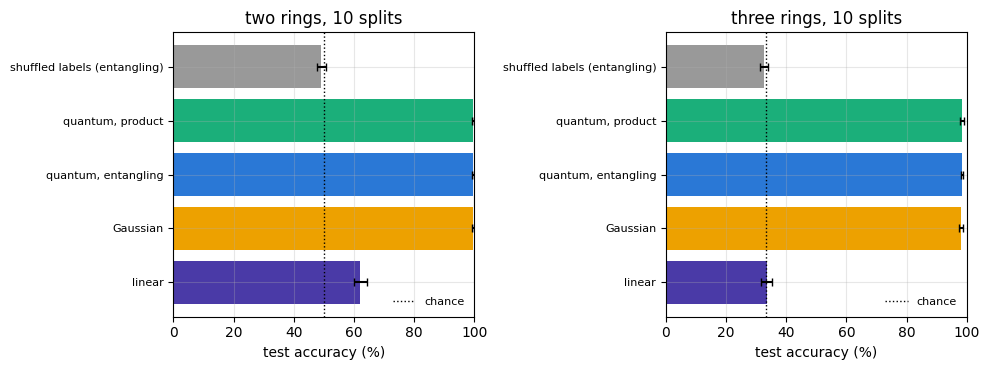

In [19]:
# ==============================================================================
# STEP 13: test accuracies over 10 splits with tuned bandwidths; shuffled-label control
# ==============================================================================
GAMMAS = [0.3, 1.0, 3.0, 10.0, 30.0, 100.0]
SCALES = [0.25, 0.5, 1.0, 1.5, 2.0, 3.0]
COMPARE = {}
t_cmp = time.perf_counter()
for name, d in DATA.items():
    X, y, nc, tr, te = d["X"], d["y"], d["n_classes"], d["train"], d["test"]
    res = {}
    acc, _ = fit_and_score(np.asarray(X @ X.T), y, tr, te, nc)
    res["linear"] = (acc, None)
    res["Gaussian"] = tune_and_score(np.stack([np.asarray(rbf_kernel(X, X, g)) for g in GAMMAS]), y, tr, te, nc)
    K_ent = np.stack([np.asarray(quantum_kernel(X, X, s, N_MAIN)) for s in SCALES])
    K_pro = np.stack([np.asarray(quantum_kernel(X, X, s, N_MAIN, entangle=False)) for s in SCALES])
    res["quantum, entangling"] = tune_and_score(K_ent, y, tr, te, nc)
    res["quantum, product"] = tune_and_score(K_pro, y, tr, te, nc)
    y_shuffled = np.asarray(jax.random.permutation(jax.random.PRNGKey(77), y))
    res["shuffled labels (entangling)"] = tune_and_score(K_ent, y_shuffled, tr, te, nc)
    COMPARE[name] = res
    print(f"{name} ({nc} classes, chance level {100 / nc:.1f} %): test accuracy, mean +- standard error over {N_SPLITS} splits")
    for model, (acc, best) in res.items():
        mu, se = mean_and_se(acc)
        grid_vals = GAMMAS if model == "Gaussian" else SCALES
        chosen = "" if best is None else "  chosen: " + ", ".join(
            f"{v:g} x{int(np.sum(np.asarray(grid_vals)[best] == v))}" for v in sorted(set(np.asarray(grid_vals)[best])))
        print(f"   {model:29s} {100 * mu:5.1f} +- {100 * se:3.1f} %{chosen}")
print(f"({time.perf_counter() - t_cmp:.1f} s for the whole comparison)")

for name, res in COMPARE.items():
    nc = DATA[name]["n_classes"]
    assert np.mean(res["linear"][0]) < 0.75                      # a straight line cannot separate rings
    assert abs(np.mean(res["shuffled labels (entangling)"][0]) - 1 / nc) < 0.12
    for model in ("Gaussian", "quantum, entangling", "quantum, product"):
        assert np.mean(res[model][0]) > 0.9

fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.8))
for ax, (name, res) in zip(axes, COMPARE.items()):
    labels_m = list(res)
    mus = [100 * np.mean(res[m][0]) for m in labels_m]
    ses = [100 * mean_and_se(res[m][0])[1] for m in labels_m]
    ax.barh(range(len(labels_m)), mus, xerr=ses, color=[PALETTE[5], PALETTE[3], PALETTE[0], PALETTE[2], "0.6"],
            capsize=3)
    ax.axvline(100 / DATA[name]["n_classes"], color="k", ls=":", lw=1, label="chance")
    ax.set_yticks(range(len(labels_m)))
    ax.set_yticklabels(labels_m, fontsize=8)
    ax.set_xlim(0, 100)
    ax.set_xlabel("test accuracy (%)")
    ax.set_title(f"{name}, {N_SPLITS} splits")
    ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()

The two controls behave as they must: the linear kernel reaches $62\,\%$ on two rings and $34\,\%$ on three, close to
the guessing levels of $50\,\%$ and $33\,\%$ (above $50\,\%$ on two rings because a line can still cut off a part of
the outer ring), and with shuffled labels the tuned quantum kernel falls to $49\,\%$ and $33\,\%$. The three
non-linear kernels are statistically indistinguishable: $99.6\pm0.3\,\%$ (Gaussian), $99.5\pm0.3\,\%$ (entangling)
and $99.5\pm0.3\,\%$ (product) on two rings, $98.1\pm0.7\,\%$, $98.5\pm0.4\,\%$ and $98.5\pm0.6\,\%$ on three. The
ten splits draw from the same 200 or 210 points, so their accuracies are correlated and the standard error
understates the uncertainty somewhat; the differences between the three kernels are smaller than one standard error
even so. The few errors are test points in the narrow radial gaps of Section 3.1. On two rings the validation picks the smoothest
candidate in most splits, $\gamma=0.3$ and $s=0.25$, because every smooth kernel already reaches $100\,\%$ on the
validation points; on three rings it prefers $s=0.5$ to $1$ and a wider range of $\gamma$. On these data the
entangling gates bring no measurable gain over the product encoding, and neither quantum kernel improves on a tuned
Gaussian kernel.

In [20]:
section_timer("7 effect of the encoding")

## 7. The effect of the encoding: scale, number of qubits and entangling gates

The tuned comparison hides how sensitive the quantum kernel is to its parameters. The first cell fixes $N=6$ and
scans the scale $s$ for both encodings without tuning; the second scans $N=2,4,\dots,10$ for the product encoding at
$s=1$ and for the entangling encoding at $s=1$ and at $s=\sqrt{6/N}$, which keeps $Ns^2$, and with it the effective
bandwidth of Eq. (19), at its value for $N=6$, $s=1$. Both cells use the two-ring set and the ten splits, and they
also record the mean off-diagonal kernel value, which shows how far the kernel has moved towards the extremes $0$
and $1$.

N = 6, scan of s:         0.25    0.5      1      2      3      4      6
   entangling test acc   99.5  100.0   99.9   98.5   87.1   72.9   61.8
   entangling train acc  99.8  100.0  100.0   99.8   99.4   99.6   99.0
   entangling mean K_ij 0.870  0.629  0.279  0.094  0.066  0.050  0.045
   product    test acc   99.4  100.0  100.0   98.8   61.0   49.0   52.8
   product    train acc  99.7  100.0  100.0   99.8   84.7   77.0   79.5
   product    mean K_ij 0.871  0.640  0.344  0.155  0.167  0.152  0.157
scan of N:                   2      4      6      8     10
   entangling, s = 1          test acc  99.4   99.9   99.9   99.9   99.9
   entangling, s = 1          mean K_ij 0.594   0.385   0.279   0.217   0.177
   entangling, s = sqrt(6/N)  test acc  95.1  100.0   99.9   99.9   99.9
   entangling, s = sqrt(6/N)  mean K_ij 0.382   0.287   0.279   0.277   0.276
   product, s = 1             test acc 100.0  100.0  100.0  100.0  100.0
   product, s = 1             mean K_ij 0.646   0.456   0.344

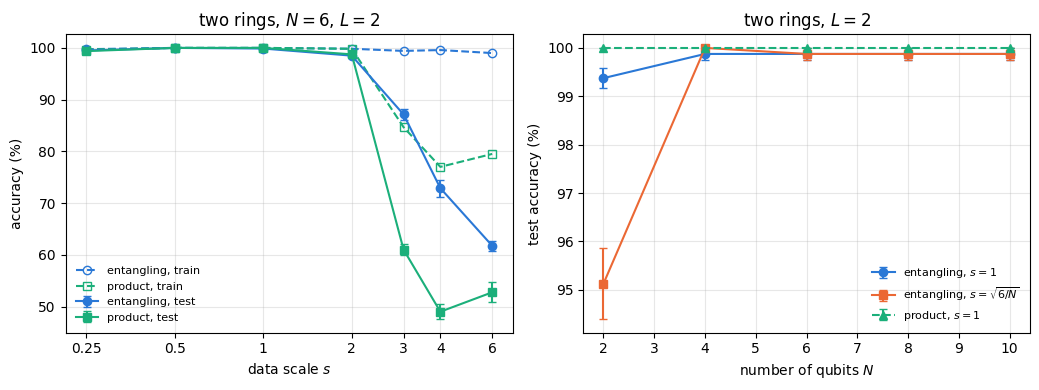

In [21]:
# ==============================================================================
# STEP 14: test accuracy versus the data scale s (N = 6) and versus the number of qubits N
# ==============================================================================
d = DATA["two rings"]
X, y, tr, te = d["X"], d["y"], d["train"], d["test"]
off = ~np.eye(X.shape[0], dtype=bool)
S_SCAN = [0.25, 0.5, 1.0, 2.0, 3.0, 4.0, 6.0]
scan_s = {}
for ent in (True, False):
    rows = []
    for s in S_SCAN:
        Kq = np.asarray(quantum_kernel(X, X, s, N_MAIN, entangle=ent))
        acc_te, acc_tr = fit_and_score(Kq, y, tr, te, 2)
        rows.append((*mean_and_se(acc_te), np.mean(acc_tr), Kq[off].mean()))
    scan_s[ent] = np.array(rows)

N_SCAN = [2, 4, 6, 8, 10]
scan_N = {}
for ent, rule in ((True, "s = 1"), (True, "s = sqrt(6/N)"), (False, "s = 1")):
    rows = []
    for N in N_SCAN:
        s = 1.0 if rule == "s = 1" else np.sqrt(6.0 / N)
        Kq = np.asarray(quantum_kernel(X, X, s, N, entangle=ent))
        acc_te, acc_tr = fit_and_score(Kq, y, tr, te, 2)
        rows.append((*mean_and_se(acc_te), np.mean(acc_tr), Kq[off].mean()))
    scan_N[(ent, rule)] = np.array(rows)

print("N = 6, scan of s:        " + "  ".join(f"{s:>5g}" for s in S_SCAN))
for ent in (True, False):
    lab = "entangling" if ent else "product"
    print(f"   {lab:10s} test acc  " + "  ".join(f"{100 * r[0]:5.1f}" for r in scan_s[ent]))
    print(f"   {lab:10s} train acc " + "  ".join(f"{100 * r[2]:5.1f}" for r in scan_s[ent]))
    print(f"   {lab:10s} mean K_ij " + "  ".join(f"{r[3]:5.3f}" for r in scan_s[ent]))
print("scan of N:               " + "  ".join(f"{N:>5d}" for N in N_SCAN))
for (ent, rule), rows in scan_N.items():
    lab = ("entangling" if ent else "product") + ", " + rule
    print(f"   {lab:26s} test acc " + "  ".join(f"{100 * r[0]:5.1f}" for r in rows))
    print(f"   {lab:26s} mean K_ij" + "  ".join(f"{r[3]:6.3f}" for r in rows))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.0))
for k, ent in enumerate((True, False)):
    lab = "entangling" if ent else "product"
    r = scan_s[ent]
    ax1.errorbar(S_SCAN, 100 * r[:, 0], yerr=100 * r[:, 1], marker=MARKERS[k], color=PALETTE[2 * k], capsize=3,
                 label=f"{lab}, test")
    ax1.plot(S_SCAN, 100 * r[:, 2], ls="--", marker=MARKERS[k], mfc="none", color=PALETTE[2 * k], label=f"{lab}, train")
ax1.set_xscale("log")
ax1.set_xticks(S_SCAN)
ax1.set_xticklabels([f"{v:g}" for v in S_SCAN])
ax1.minorticks_off()
ax1.set_xlabel("data scale $s$")
ax1.set_ylabel("accuracy (%)")
ax1.set_title(f"two rings, $N={N_MAIN}$, $L=2$")
ax1.legend(fontsize=8)
for k, ((ent, rule), rows) in enumerate(scan_N.items()):
    lab = ("entangling" if ent else "product") + (", $s=1$" if rule == "s = 1" else r", $s=\sqrt{6/N}$")
    ax2.errorbar(N_SCAN, 100 * rows[:, 0], yerr=100 * rows[:, 1], marker=MARKERS[k], color=PALETTE[k], capsize=3,
                 ls="-" if ent else "--", label=lab)
ax2.set_xlabel("number of qubits $N$")
ax2.set_ylabel("test accuracy (%)")
ax2.set_title("two rings, $L=2$")
ax2.legend(fontsize=8)
fig.tight_layout()
plt.show()

Small and moderate scales, $0.25\leq s\leq2$, give test accuracies between $98.5\,\%$ and $100\,\%$ for both
encodings. Beyond $s=2$ they fail in two different ways. For the entangling encoding the training accuracy stays at
$99\,\%$ or more while the test accuracy drops to $87\,\%$, $73\,\%$ and $62\,\%$ at $s=3,4,6$; the mean off-diagonal
kernel value falls to $0.05$, the kernel matrix approaches the identity, every point is similar only to itself, and the
SVM memorises the training set, which is overfitting. For the product encoding the training accuracy also falls, to
$77$–$85\,\%$, and the test accuracy drops to $61\,\%$ at $s=3$ and to the guessing level at $s=4$ and $6$. The
single-qubit kernels are periodic in the coordinates with period $\pi/s$, for any number of layers, because
$R_z(\theta+2\pi)=-R_z(\theta)$ changes only the global phase; at large $s$ points far apart look similar, and the
kernel no longer reflects the geometry of the data, which is underfitting. The mean kernel value of the product
encoding stays near $0.15$ and does not reveal this. The Gaussian picture of Eq. (19) fails in this regime, since it
requires $s\vert\tilde x_q-\tilde x_q'\vert\ll1$. At the other end, $s\to0$, every kernel tends to the constant $1$ and
every point looks like every other.

Against $N$ the picture is flat on this data set: at $s=1$ the test accuracy is $99.4\,\%$ for $N=2$ and $99.9\,\%$ for
$N=4$ to $10$ with the entangling encoding, and $100\,\%$ for every $N$ with the product encoding, while the mean
kernel value decreases from $0.59$ to $0.18$ (entangling) and from $0.65$ to $0.22$ (product). The rule
$s=\sqrt{6/N}$ keeps the mean kernel value of the entangling encoding constant, $0.28$, from $N=4$ to $N=10$, as
Eq. (19) suggests although it was derived for the product encoding with one layer. At $N=2$ it requires $s=\sqrt3$,
and the test accuracy drops to $95\,\%$. More qubits add no information here, because the data have two features
whatever $N$ is.

In [22]:
section_timer("8 concentration")

## 8. Concentration of kernel values with the number of qubits

For a kernel to be useful its off-diagonal values must vary from pair to pair, and on a device these variations must
be larger than the shot noise. A reference point is the overlap of two independent Haar-random states in dimension
$D=2^N$. The amplitudes of a Haar-random state are independent complex Gaussian numbers $g_n$ divided by their norm,
so $p=\vert\langle a\vert b\rangle\vert^2$ has the distribution of $\vert g_1\vert^2/\sum_n\vert g_n\vert^2$, where the
$\vert g_n\vert^2$ are independent exponential random numbers. This ratio has the Beta distribution with parameters
$(1,D-1)$, whose first two moments are $\mathbb E\,p=1/D$ and $\mathbb E\,p^2=2/\big(D(D+1)\big)$, so

$$\mathbb E\,k_{\rm Haar}=\frac1{2^N},\qquad \mathrm{Var}\,k_{\rm Haar}=\frac{2}{D(D+1)}-\frac1{D^2}=\frac{D-1}{D^2(D+1)}\approx\frac1{4^N}. \tag{25}$$

Both mean and spread vanish exponentially. The number of shots needed to see the differences between kernel values
follows from a comparison of two variances. The shot noise of one entry, Eq. (20), has variance $k(1-k)/S$; with $k$
replaced by its mean, it is smaller than the spread of the kernel values across pairs, $\mathrm{Var}\,k$, once

$$S\ \gtrsim\ S^*=\frac{\mathbb E\,k\,(1-\mathbb E\,k)}{\mathrm{Var}\,k},\qquad S^*_{\rm Haar}=D+1=2^N+1 , \tag{26}$$

where the last value follows from Eq. (25). An encoding whose states look Haar-random needs a number of shots per
kernel entry that doubles with every qubit. Thanasilp *et al.* (2024) proved bounds of this type for expressive
encodings, global measurements, entanglement and noise.

The cell measures $\mathbb E\,k$, $\mathrm{Var}\,k$ and $S^*$ over all pairs of 200 points in four settings. The
two-ring data, which have two features repeated over the qubits, are encoded with the entangling circuit at $s=1$ and
at $s=\sqrt{6/N}$ for even $N=2,\dots,10$. Random data with one feature per qubit, $x_q$ uniform in $[-1,1]$, are
encoded for $N=2,\dots,10$ at $s=\pi/2$, so that every single-qubit angle $2sx_q$ ranges over a full period, once with
the entangling and once with the product circuit; the product kernel is evaluated through Eq. (18) as a product of
$N$ one-qubit kernels, which needs a single compiled circuit for all $N$ and is checked against the six-qubit circuit.
The Haar values of Eq. (25) are checked against 200 sampled Haar states at $N=6$.

product kernel from single-qubit kernels, Eq. (18), N = 6: max deviation from the circuit 2.7e-15


Haar states, N = 6: mean 0.01569 (Eq. 25: 0.01562), variance 2.43e-04 (Eq. 25: 2.37e-04), S* = 63.5 (Eq. 26: 65)

rings, entangling, s = 1
   N               2        4        6        8       10
   mean     5.94e-01 3.85e-01 2.79e-01 2.17e-01 1.77e-01
   variance 5.04e-02 7.26e-02 7.30e-02 6.74e-02 6.10e-02
   S*            4.8      3.3      2.8      2.5      2.4

rings, entangling, s = sqrt(6/N)
   N               2        4        6        8       10
   mean     3.82e-01 2.87e-01 2.79e-01 2.77e-01 2.76e-01
   variance 7.34e-02 7.22e-02 7.30e-02 7.37e-02 7.44e-02
   S*            3.2      2.8      2.8      2.7      2.7

random x in [-1,1]^N, entangling, s = pi/2
   N               2        3        4        5        6        7        8        9       10
   mean     3.40e-01 1.95e-01 1.06e-01 5.66e-02 3.22e-02 1.60e-02 8.36e-03 5.45e-03 2.64e-03
   variance 5.99e-02 3.01e-02 1.26e-02 5.11e-03 2.07e-03 7.25e-04 2.51e-04 1.13e-04 4.03e-05
   S*            3.7      5.2      7.5     10.4 

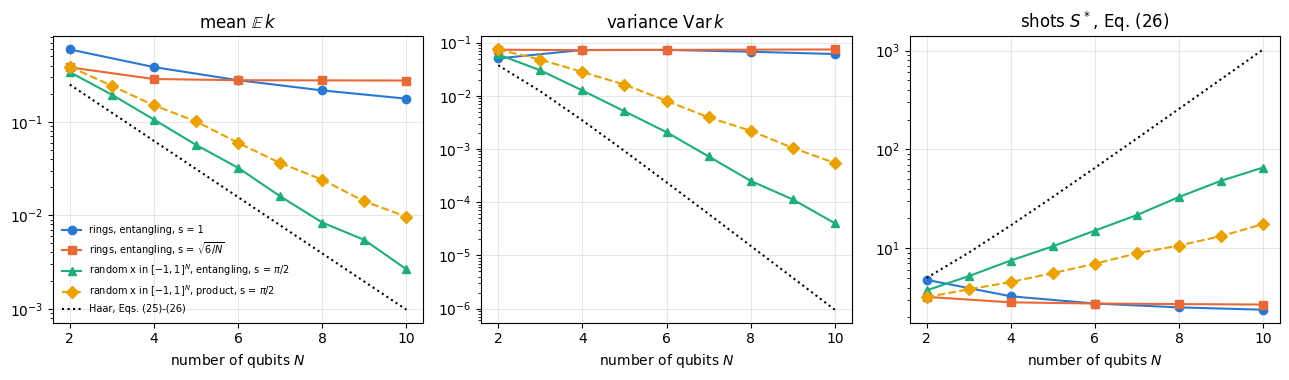

In [23]:
# ==============================================================================
# STEP 15: mean, variance and S* of off-diagonal kernel values for N = 2..10
# ==============================================================================
N_CONC = list(range(2, 11))
N_PTS_CONC = 200
iu = np.triu_indices(N_PTS_CONC, 1)


def offdiag_stats(K):
    """Mean, variance and S* = mean (1 - mean) / variance of the upper off-diagonal entries (Eq. 26)."""
    v = np.asarray(K)[iu]
    m, var = v.mean(), v.var()
    return m, var, m * (1 - m) / var


X_rings = DATA["two rings"]["X"]
conc = {}                                                     # setting -> (list of N, list of statistics)
for N in N_CONC:
    X_rand = 2 * jax.random.uniform(jax.random.PRNGKey(300 + N), (N_PTS_CONC, N), dtype=RDTYPE) - 1
    settings = {"random x in [-1,1]^N, entangling, s = pi/2":
                    lambda: quantum_kernel(X_rand, X_rand, np.pi / 2, N),
                # product encoding: Eq. (18), one single-qubit kernel per feature (one compilation for all N)
                "random x in [-1,1]^N, product, s = pi/2":
                    lambda: np.prod([np.asarray(quantum_kernel(X_rand[:, q:q + 1], X_rand[:, q:q + 1], np.pi / 2, 1,
                                                               entangle=False)) for q in range(N)], axis=0)}
    if N % 2 == 0:                                            # the two-feature ring data on an even number of qubits
        settings["rings, entangling, s = 1"] = lambda: quantum_kernel(X_rings, X_rings, 1.0, N)
        settings["rings, entangling, s = sqrt(6/N)"] = lambda: quantum_kernel(X_rings, X_rings, np.sqrt(6.0 / N), N)
    for lab, make_K in settings.items():
        Ns, stats = conc.setdefault(lab, ([], []))
        Ns.append(N)
        stats.append(offdiag_stats(make_K()))
conc = {k: (np.array(Ns), np.array(v)) for k, (Ns, v) in conc.items()}
conc = {k: conc[k] for k in ("rings, entangling, s = 1", "rings, entangling, s = sqrt(6/N)",
                             "random x in [-1,1]^N, entangling, s = pi/2", "random x in [-1,1]^N, product, s = pi/2")}
X_check = 2 * jax.random.uniform(jax.random.PRNGKey(306), (N_PTS_CONC, 6), dtype=RDTYPE) - 1
err_eq18 = max_abs(quantum_kernel(X_check, X_check, np.pi / 2, 6, entangle=False) - np.prod(
    [np.asarray(quantum_kernel(X_check[:, q:q + 1], X_check[:, q:q + 1], np.pi / 2, 1, entangle=False))
     for q in range(6)], axis=0))
print(f"product kernel from single-qubit kernels, Eq. (18), N = 6: max deviation from the circuit {err_eq18:.1e}")
assert err_eq18 < TOL

D6 = 2 ** 6
haar = jax.vmap(lambda k: haar_state(k, 6).reshape(-1))(jax.random.split(jax.random.PRNGKey(9), N_PTS_CONC))
m_h, v_h, S_h = offdiag_stats(kernel_from_states(haar, haar))
print(f"Haar states, N = 6: mean {m_h:.5f} (Eq. 25: {1 / D6:.5f}), variance {v_h:.2e} "
      f"(Eq. 25: {(D6 - 1) / (D6 ** 2 * (D6 + 1)):.2e}), S* = {S_h:.1f} (Eq. 26: {D6 + 1})")
assert abs(m_h * D6 - 1) < 0.1 and abs(S_h / (D6 + 1) - 1) < 0.2

for lab, (Ns, arr) in conc.items():
    print(f"\n{lab}")
    print("   N        " + " ".join(f"{N:>8d}" for N in Ns))
    print("   mean     " + " ".join(f"{m:8.2e}" for m in arr[:, 0]))
    print("   variance " + " ".join(f"{v:8.2e}" for v in arr[:, 1]))
    print("   S*       " + " ".join(f"{S:8.1f}" for S in arr[:, 2]))

fig, axes = plt.subplots(1, 3, figsize=(13.0, 3.9))
NN = np.array(N_CONC)
for k, (lab, (Ns, arr)) in enumerate(conc.items()):
    ls = "-" if "entangling" in lab else "--"
    for ax, col in zip(axes, range(3)):
        ax.plot(Ns, arr[:, col], marker=MARKERS[k], ls=ls, color=PALETTE[k], label=lab.replace("sqrt(6/N)", r"$\sqrt{6/N}$").replace("pi/2", r"$\pi/2$")
                .replace("[-1,1]^N", r"$[-1,1]^N$"))
Dn = 2.0 ** NN
for ax, ref, title in zip(axes, [1 / Dn, (Dn - 1) / (Dn ** 2 * (Dn + 1)), Dn + 1],
                          [r"mean $\mathbb{E}\,k$", r"variance $\mathrm{Var}\,k$", r"shots $S^*$, Eq. (26)"]):
    ax.plot(NN, ref, "k:", lw=1.5, label="Haar, Eqs. (25)-(26)")
    ax.set_yscale("log")
    ax.set_xlabel("number of qubits $N$")
    ax.set_title(title)
axes[0].legend(fontsize=7, loc="lower left")
fig.tight_layout()
plt.show()

The sampled Haar states reproduce Eq. (25): mean $0.01569$ against $1/64=0.01562$, variance $2.43\times10^{-4}$
against $2.37\times10^{-4}$, and $S^*=63.5$ against $65$.

The two-ring data do not concentrate. At $s=1$ the mean kernel value decreases from $0.59$ at $N=2$ to $0.18$ at
$N=10$, but the variance stays between $0.05$ and $0.07$, and $S^*$ even decreases, from $4.8$ to $2.4$: a handful of
shots per entry resolves the differences between kernel values. With $s=\sqrt{6/N}$ all three quantities are nearly
independent of $N$. Whatever the number of qubits, these states are generated by two numbers, and they explore only
a two-dimensional family of states inside the $2^N$-dimensional space.

Random data with one feature per qubit behave differently. With the entangling encoding the mean falls from $0.34$
at $N=2$ to $2.6\times10^{-3}$ at $N=10$, about a factor $1.8$ per qubit, the variance from $6\times10^{-2}$ to
$4\times10^{-5}$, and $S^*$ grows from $3.7$ to $66$, approximately exponentially, more slowly than the Haar value
$2^N+1=1025$ at $N=10$; the mean is $2.7$ times the Haar value $2^{-10}$. The product encoding concentrates more
slowly still, mean $9.7\times10^{-3}$ and $S^*=17.5$ at $N=10$, because its kernel is a product of independent
single-qubit factors with independent features, $\mathbb E\,k=(\mathbb E\,\kappa)^N$ and
$\mathbb E\,k^2=(\mathbb E\,\kappa^2)^N$. For small $\mathbb E\,k$, Eq. (26) gives
$S^*\approx\mathbb E\,k/\mathrm{Var}\,k=(\mathbb E\,\kappa)^N/\big[(\mathbb E\,\kappa^2)^N-(\mathbb E\,\kappa)^{2N}\big]$, which
grows like $(\mathbb E\,\kappa/\mathbb E\,\kappa^2)^N$; the measured moments correspond to a factor of about $1.3$ per
qubit.
In both cases the growth is exponential in $N$: an encoding that spreads $N$ independent features over the Hilbert
space produces kernel values that a device can resolve only with exponentially many shots. Section 9 shows the
consequence for the classification of the rings, where it is mild.

In [24]:
section_timer("9 finite shots")

## 9. Classification with kernels estimated from finite shots

On a device every entry of the training kernel matrix and of the test-versus-training matrix is an estimate from $S$
shots of the inversion test. The cell draws the counts directly from the binomial distribution with the exact kernel
as success probability, which Section 4.4 showed to be equivalent to sampling bit strings; the diagonal is set to its
known value $1$ and the training matrix is kept symmetric (each pair measured once). A matrix of estimates is not
PSD in general. We train the SVM on it as it is, and also after the common repair of setting its negative
eigenvalues to zero, $\hat K\to V\max(\Lambda,0)V^{\rm T}$, which gives the nearest PSD matrix in the Frobenius norm
$\Vert A\Vert_F=\big(\sum_{ij}A_{ij}^2\big)^{1/2}$.
Two kernels are compared on the two-ring set: the entangling encoding with $N=6$, $s=1$, used so far, and with
$N=10$, $s=2$, a narrower kernel with much smaller off-diagonal values (Section 7). Every split and every number of
shots has its own random key. The total number of circuit runs for one training matrix is
$S\,M_{\rm tr}(M_{\rm tr}-1)/2$, about $7\times10^3\,S$ for $M_{\rm tr}=120$.

N = 6, s = 1.0: exact kernel 99.9 +- 0.1 %; off-diagonal entries: mean 0.279, fraction below 0.05: 0.21, S* of Eq. (26) 2.8
   S =     10: raw  94.0 +- 0.7 %,  PSD-repaired  94.6 +- 0.9 %,  negative eigenvalues of the training matrix: 50.2 of 120
   S =     30: raw  97.0 +- 0.5 %,  PSD-repaired  98.5 +- 0.5 %,  negative eigenvalues of the training matrix: 48.3 of 120
   S =    100: raw  98.8 +- 0.5 %,  PSD-repaired  99.4 +- 0.3 %,  negative eigenvalues of the training matrix: 45.5 of 120
   S =   1000: raw  99.9 +- 0.1 %,  PSD-repaired  99.9 +- 0.1 %,  negative eigenvalues of the training matrix: 41.4 of 120
   S =  10000: raw  99.9 +- 0.1 %,  PSD-repaired  99.9 +- 0.1 %,  negative eigenvalues of the training matrix: 37.1 of 120


N = 10, s = 2.0: exact kernel 98.3 +- 0.3 %; off-diagonal entries: mean 0.049, fraction below 0.05: 0.83, S* of Eq. (26) 2.4
   S =     10: raw  96.8 +- 1.0 %,  PSD-repaired  96.4 +- 1.0 %,  negative eigenvalues of the training matrix: 26.0 of 120
   S =     30: raw  98.0 +- 0.4 %,  PSD-repaired  98.1 +- 0.3 %,  negative eigenvalues of the training matrix: 20.4 of 120
   S =    100: raw  97.8 +- 0.3 %,  PSD-repaired  97.6 +- 0.3 %,  negative eigenvalues of the training matrix: 17.7 of 120
   S =   1000: raw  98.3 +- 0.3 %,  PSD-repaired  98.3 +- 0.3 %,  negative eigenvalues of the training matrix: 12.5 of 120
   S =  10000: raw  98.3 +- 0.3 %,  PSD-repaired  98.3 +- 0.3 %,  negative eigenvalues of the training matrix: 8.6 of 120


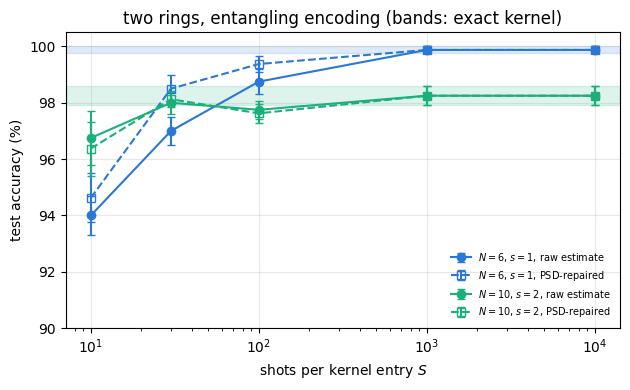

In [25]:
# ==============================================================================
# STEP 16: test accuracy versus shots per kernel entry (binomial estimates, raw and PSD-repaired)
# ==============================================================================
def shot_kernel(key, K, shots, symmetric):
    """Estimate of K from `shots` inversion-test shots per entry: Binomial(shots, K) / shots.

    If `symmetric`, only the upper triangle is drawn and mirrored, and the diagonal is set to 1 (known exactly).
    """
    est = jax.random.binomial(key, shots, jnp.clip(K, 0.0, 1.0)).astype(RDTYPE) / shots
    if symmetric:
        upper = jnp.triu(est, 1)
        est = upper + upper.T + jnp.eye(K.shape[0], dtype=RDTYPE)
    return est


def psd_repair(K):
    """Nearest positive semidefinite matrix in the Frobenius norm: negative eigenvalues set to zero."""
    lam, V = np.linalg.eigh(np.asarray(K))
    return (V * np.maximum(lam, 0.0)) @ V.T, int(np.sum(lam < 0)), lam[0]


SHOTS = [10, 30, 100, 1000, 10000]
shot_res = {}
for (N, s) in ((6, 1.0), (10, 2.0)):
    Kq = np.asarray(quantum_kernel(X, X, s, N))
    acc_exact, _ = fit_and_score(np.asarray(Kq), y, tr, te, 2)
    rows = []
    for n_sh, shots in enumerate(SHOTS):
        K_raw, K_fix, n_neg = [], [], []
        for sp in range(N_SPLITS):
            k_tr, k_te = jax.random.split(jax.random.PRNGKey(1000 * N + 10 * n_sh + sp))
            Ktt = np.asarray(shot_kernel(k_tr, Kq[np.ix_(tr[sp], tr[sp])], shots, True))
            Kte = np.asarray(shot_kernel(k_te, Kq[np.ix_(te[sp], tr[sp])], shots, False))
            Kfix, nn, _ = psd_repair(Ktt)
            n_neg.append(nn)
            # assemble per-split full matrices so that fit_and_score can index them
            for store, Kt in ((K_raw, Ktt), (K_fix, Kfix)):
                Kf = np.zeros((X.shape[0], X.shape[0]))
                Kf[np.ix_(tr[sp], tr[sp])] = Kt
                Kf[np.ix_(te[sp], tr[sp])] = Kte
                store.append(Kf)
        a_raw, _ = fit_and_score(np.stack(K_raw), y, tr, te, 2)
        a_fix, _ = fit_and_score(np.stack(K_fix), y, tr, te, 2)
        rows.append((*mean_and_se(a_raw), *mean_and_se(a_fix), np.mean(n_neg)))
    shot_res[(N, s)] = (np.array(rows), mean_and_se(acc_exact))
    off_vals = Kq[~np.eye(Kq.shape[0], dtype=bool)]
    print(f"N = {N}, s = {s}: exact kernel {100 * np.mean(acc_exact):.1f} +- {100 * mean_and_se(acc_exact)[1]:.1f} %; "
          f"off-diagonal entries: mean {off_vals.mean():.3f}, fraction below 0.05: {np.mean(off_vals < 0.05):.2f}, "
          f"S* of Eq. (26) {offdiag_stats(Kq)[2]:.1f}")
    for shots, r in zip(SHOTS, rows):
        print(f"   S = {shots:6d}: raw {100 * r[0]:5.1f} +- {100 * r[1]:3.1f} %,  PSD-repaired {100 * r[2]:5.1f} +- "
              f"{100 * r[3]:3.1f} %,  negative eigenvalues of the training matrix: {r[4]:.1f} of {tr.shape[1]}")

fig, ax = plt.subplots(figsize=(6.4, 4.0))
for k, ((N, s), (rows, (m_ex, se_ex))) in enumerate(shot_res.items()):
    ax.errorbar(SHOTS, 100 * rows[:, 0], yerr=100 * rows[:, 1], marker="o", color=PALETTE[2 * k], capsize=3,
                label=f"$N={N}$, $s={s:g}$, raw estimate")
    ax.errorbar(SHOTS, 100 * rows[:, 2], yerr=100 * rows[:, 3], marker="s", mfc="none", ls="--", color=PALETTE[2 * k],
                capsize=3, label=f"$N={N}$, $s={s:g}$, PSD-repaired")
    ax.axhspan(100 * (m_ex - se_ex), 100 * (m_ex + se_ex), color=PALETTE[2 * k], alpha=0.15)
ax.set_ylim(90, 100.5)                                                  # chance level 50 % lies far below
ax.set_xscale("log")
ax.set_xlabel("shots per kernel entry $S$")
ax.set_ylabel("test accuracy (%)")
ax.set_title("two rings, entangling encoding (bands: exact kernel)")
ax.legend(fontsize=7, loc="lower right")
fig.tight_layout()
plt.show()

With the kernel of $N=6$, $s=1$ the accuracy falls from $99.9\,\%$ (exact kernel and $S\geq1000$) to $98.8\,\%$ at
$S=100$, $97.0\,\%$ at $S=30$ and $94.0\,\%$ at $S=10$. Removing the negative eigenvalues helps at intermediate shot
numbers, $98.5\,\%$ instead of $97.0\,\%$ at $S=30$ and $99.4\,\%$ instead of $98.8\,\%$ at $S=100$. The estimated
training matrix is far from PSD: it has about 50 negative eigenvalues out of 120 at $S=10$ and still 37 at
$S=10^4$, because the exact matrix has many eigenvalues close to zero, which any perturbation pushes to either sign.
The SVM nevertheless trains on the raw estimates without difficulty, as the sigmoid kernel did in Section 3.5.

The kernel with $N=10$, $s=2$ has smaller off-diagonal values and a slightly lower exact accuracy, $98.3\,\%$, but it
is more robust to shot noise: $96.8\,\%$ at $S=10$ and the exact value from $S=1000$ on. Eq. (20) explains part of
this: the variance of an inversion-test estimate, $k(1-k)/S$, is small when $k$ is small, and the off-diagonal entries
of this kernel are small: their mean is $0.049$ against $0.279$ for $N=6$, $s=1$, and $83\,\%$ of them lie below $0.05$. A device would need about $7\times10^3\,S$ circuit runs for one
training matrix, $7\times10^5$ at $S=100$, plus $9.6\times10^3\,S$ for the test points. These numbers are modest
because the kernel values of the ring data do not concentrate (Section 8): $S^*$ of Eq. (26) is $2.8$ for the
six-qubit kernel and $2.4$ for the ten-qubit one, while the random data of Section 8 at $N=10$ have $S^*=66$, 27
times more.

In [26]:
section_timer("10 cost")

## 10. Cost of the simulation

The cell times the two ways of computing the kernel matrix of the 200 points of the two-ring set for $N=6$ and $N=10$,
each compiled once before timing, and one batch of ten SVMs. It closes with the wall-clock time of each section of
this notebook.

In [27]:
# ==============================================================================
# STEP 17: timings of the kernel matrix and of the SVM solver
# ==============================================================================
def timed(fn, *args, repeats=3):
    """Median wall time of an already compiled call (one warm-up call first)."""
    jax.block_until_ready(fn(*args))
    ts = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        jax.block_until_ready(fn(*args))
        ts.append(time.perf_counter() - t0)
    return float(np.median(ts))


for N in (6, 10):
    t_pairs = timed(lambda A: inversion_test_p0(A, A, 1.0, N), X2[:20], repeats=1)
    t_states = timed(lambda A: quantum_kernel(A, A, 1.0, N), X2, repeats=1)
    print(f"N = {N:2d}: inversion test, 20 x 20 pairs: {t_pairs * 1e3:7.1f} ms  ({t_pairs / 400 * 1e6:.1f} us per pair);"
          f"  state shortcut, 200 x 200: {t_states * 1e3:6.1f} ms")
K10 = jnp.asarray(np.stack([np.asarray(K_sim)[np.ix_(t, t)] for t in tr]))
Y10 = jnp.asarray(np.stack([np.where(y[t] == 1, 1.0, -1.0) for t in tr]))
t_svm = timed(lambda A, B: svm_solve_batch(A, B, C_SVM), K10, Y10, repeats=1)
print(f"10 SVMs of {tr.shape[1]} points, {N_ITER} FISTA iterations, one vmapped call: {t_svm:.2f} s")

section_timer("end")
print("\nwall-clock time per section:")
for k, v in SECTION_TIMES.items():
    if k != "end":
        print(f"   {k:36s} {v:6.1f} s")
print(f"   {'total (Sections 3-10)':36s} {sum(v for k, v in SECTION_TIMES.items() if k != 'end'):6.1f} s")

N =  6: inversion test, 20 x 20 pairs:     4.0 ms  (10.1 us per pair);  state shortcut, 200 x 200:    4.4 ms


N = 10: inversion test, 20 x 20 pairs:    74.9 ms  (187.3 us per pair);  state shortcut, 200 x 200:   69.1 ms


10 SVMs of 120 points, 600 FISTA iterations, one vmapped call: 0.04 s

wall-clock time per section:
   3 classical kernel methods              5.5 s
   4 quantum feature map                   4.4 s
   5 classification at N = 6               4.0 s
   6 comparison with classical kernels     6.2 s
   7 effect of the encoding                4.2 s
   8 concentration                         8.0 s
   9 finite shots                          3.8 s
   10 cost                                 1.7 s
   total (Sections 3-10)                  37.8 s


The timings depend on the machine and its load; on a shared CPU they vary by a factor of a few between runs. In the
run shown, one inversion-test circuit costs about $10\,\mu$s at $N=6$ and $0.2$ ms at $N=10$, while the shortcut
computes the whole $200\times200$ matrix in a few milliseconds at $N=6$ and in about $70$ ms at $N=10$. The forty
thousand overlap circuits of the full matrix at $N=10$ would take about eight seconds, about a hundred times longer than
the shortcut, which prepares each of the 200 states once and obtains all overlaps from one matrix product. Ten SVMs
of 120 points take a fraction of a second in one vmapped call. The cost of a state grows as
$2^N$ times the number of gates, and the cost of the kernel matrix as $M$ states plus $M^2\,2^N$ for the product; for
$N\leq10$ and a few hundred points everything fits in memory. The section times above include compilation, which
dominates for the many encoding circuits of Sections 7 and 8.

## 11. Key takeaways

* **A kernel method needs only the kernel matrix.** The SVM dual, Eq. (9), contains the feature vectors only through
  $K_{ij}$, and the decision function, Eq. (12), only through kernel values with the training points. The JAX solver
  (FISTA with an exact projection, Eq. (14)) reached a relative duality gap of $9\times10^{-11}$ and agreed with
  scikit-learn to $4\times10^{-7}$.
* **A quantum kernel is an overlap of encoded states.** The fidelity kernel of Eq. (5) is PSD because it is the
  scalar product of $\vert\phi\rangle\otimes\vert\bar\phi\rangle$, Eq. (17); the modulus of the overlap is not PSD
  (71 negative eigenvalues of 200). The inversion test, run as $10^4$ circuits with a double `vmap`, agreed with the
  state shortcut to $3\times10^{-15}$, and the swap test on $2N+1$ qubits gave $(1+k)/2$ to round-off but needs about
  $(1+k)/k$ times more shots.
* **The data scale is a bandwidth.** The product encoding with one layer is close to a Gaussian kernel with
  $\gamma_{\rm eff}=Ns^2/d$, Eq. (19). Large scales fail: the entangling kernel overfits (test accuracy $62\,\%$ at
  $s=6$ with training accuracy $99\,\%$), the periodic product kernel underfits and drops to guessing.
* **No advantage on the rings.** With bandwidths tuned on held-out data over ten splits, the entangling, product and
  Gaussian kernels reached $99.5$–$99.6\,\%$ on two rings and $98.1$–$98.5\,\%$ on three, equal within the error bars;
  the linear kernel ($62\,\%$ and $34\,\%$) and shuffled labels ($49\,\%$ and $33\,\%$) stayed near the guessing
  level, as they must.
* **Kernel PCA shows the geometry.** Three components hold $45\,\%$ of the variance and separate the two rings by a
  plane; the kernel matrix sorted by class has a strong inner-ring block and weak, non-orthogonal off-diagonal blocks.
* **Expressive encodings concentrate.** For random data with one feature per qubit the mean kernel value and its
  variance decay exponentially with $N$, and the number of shots $S^*$ needed to resolve the kernel grows with $N$;
  Haar-random states give $S^*=2^N+1$, Eq. (26). The two-feature ring data do not concentrate, and rescaling
  $s\propto1/\sqrt N$ keeps their mean kernel value constant.
* **Shots and positivity.** Kernel matrices estimated from $S$ shots have tens of negative eigenvalues even at
  $S=10^4$; for the six-qubit kernel the accuracy dropped from $99.9\,\%$ to $94\,\%$ at $S=10$, and removing the
  negative eigenvalues recovered part of the loss at $S=30$–$100$.

## 12. Exercises

1. ★ **Swap test or inversion test.** Using Eqs. (20) and (22), compute the number of shots needed to estimate a kernel
   value $k=0.05$ with standard deviation $0.01$ by each test. (Check: $475$ and $9975$.)
2. ★ **The Haar reference.** Repeat the Haar check of Section 8 for $N=8$ with 300 states drawn from
   `jax.random.split(jax.random.PRNGKey(21), 300)` and compare $S^*$ with Eq. (26). (Check: $S^*\approx257$, sampled
   value $256.7$.)
3. ★★ **Number of layers.** Repeat the two-ring classification of Section 7 at $N=6$, $s=1$ for $L=1,2,3$ (no tuning,
   ten splits). How do the mean off-diagonal kernel value and the test accuracy change? (Check: mean kernel values
   $0.258$, $0.279$, $0.154$; test accuracies $99.6$, $99.9$ and $98.6\,\%$.)
4. ★★ **Kernel-target alignment.** The alignment
   $A=\sum_{ij}K_{ij}y_iy_j\big/\big(M\Vert K\Vert_F\big)$ measures how well $K$ resembles the ideal matrix
   $\mathbf y\mathbf y^{\rm T}$ (Hubregtsen *et al.*, 2022). Compute it for the entangling kernel at $N=6$ on all 200
   points of the two-ring set for $s\in\{0.25,0.5,0.75,1,1.25,1.5,2,3\}$. Which $s$ maximises it, and does that agree
   with the scale chosen by validation in Section 6? (Check: maximum $A=0.411$ at $s=1.5$.)
5. ★★ **The pair angle of Havlíček *et al.* (extend the code).** Replace the angle of the $R_{ZZ}$ gates in
   `feature_circuit` by $2(\pi-\tilde x_q)(\pi-\tilde x_{q+1})$, keep $R_z(2s\tilde x_q)$ with $s=1$, and repeat the
   untuned two-ring classification at $N=6$. (Check: mean off-diagonal kernel value $0.076$, test accuracy
   $98.0\,\%$.)
6. ★★ **Kernel ridge classification.** Replace the SVM by the solution of $(K+\lambda\mathbb 1)\boldsymbol\beta=\mathbf y$
   and the decision function $f(\mathbf x)=\sum_i\beta_ik(\mathbf x_i,\mathbf x)$. With $\lambda=0.1$ and the entangling
   kernel at $N=6$, $s=1$, compare the test accuracy with the SVM over the ten splits. Which training points enter
   $f$? (Check: $99.9\,\%$.)
7. ★★★ **A projected quantum kernel (physics).** Huang *et al.* (2021) proposed kernels built from local
   quantities, for example $k(\mathbf x,\mathbf x')=\exp\big(-\gamma\sum_q\Vert\rho_q(\mathbf x)-\rho_q(\mathbf x')\Vert_F^2\big)$ with
   the one-qubit reduced density matrices $\rho_q$. For the random data of Section 8 (150 points, keys
   `jax.random.PRNGKey(300 + N)`, entangling encoding, $s=\pi/2$, $\gamma=1$), compute $S^*$ of Eq. (26) for
   $N=4,6,8,10$ and compare with the fidelity kernel. Why do local quantities concentrate more slowly? (Check: $S^*$ of
   the projected kernel $7.5$, $10.9$, $12.7$, $18.4$; of the fidelity kernel $7.5$, $14.4$, $32.8$, $63.6$.)

## References

* V. Havlíček, A. D. Córcoles, K. Temme, A. W. Harrow, A. Kandala, J. M. Chow and J. M. Gambetta, *Supervised
  learning with quantum-enhanced feature spaces*, Nature **567**, 209 (2019) — the quantum kernel estimator and the
  variational quantum classifier, run on two superconducting qubits; encoding circuits of the type of Eq. (16).
* M. Schuld and N. Killoran, *Quantum machine learning in feature Hilbert spaces*, Phys. Rev. Lett. **122**, 040504
  (2019) — the encoding of data into quantum states as a feature map, and kernels computed from state overlaps.
* Y. Liu, S. Arunachalam and K. Temme, *A rigorous and robust quantum speed-up in supervised machine learning*,
  Nat. Phys. **17**, 1013 (2021) — a classification problem based on the discrete logarithm on which a quantum-kernel
  SVM is provably better than any classical learner, under the assumption that the discrete logarithm is hard.
* H.-Y. Huang, M. Broughton, M. Mohseni, R. Babbush, S. Boixo, H. Neven and J. R. McClean, *Power of data in quantum
  machine learning*, Nat. Commun. **12**, 2631 (2021) — classical learners given data can compete with quantum models;
  a test for a potential quantum advantage of a kernel on a given data set.
* S. Thanasilp, S. Wang, M. Cerezo and Z. Holmes, *Exponential concentration in quantum kernel methods*,
  Nat. Commun. **15**, 5200 (2024) — concentration of kernel values from expressivity, global measurements,
  entanglement and noise, and the resulting number of shots (Section 8).
* R. Shaydulin and S. M. Wild, *Importance of kernel bandwidth in quantum machine learning*, Phys. Rev. A **106**,
  042407 (2022) — the data scale as the bandwidth of a quantum kernel (Sections 4.3 and 7).
* T. Hubregtsen, D. Wierichs, E. Gil-Fuster, P.-J. H. S. Derks, P. K. Faehrmann and J. J. Meyer, *Training quantum
  embedding kernels on near-term quantum computers*, Phys. Rev. A **106**, 042431 (2022) — trainable encodings
  optimised by kernel-target alignment, noise and finite sampling in kernel matrices (Exercise 4).
* H. Buhrman, R. Cleve, J. Watrous and R. de Wolf, *Quantum fingerprinting*, Phys. Rev. Lett. **87**, 167902 (2001) —
  the swap test (Section 4.4).
* C. Cortes and V. Vapnik, *Support-vector networks*, Mach. Learn. **20**, 273 (1995) — the soft-margin support
  vector machine of Eq. (6).
* B. Schölkopf, A. Smola and K.-R. Müller, *Nonlinear component analysis as a kernel eigenvalue problem*, Neural
  Comput. **10**, 1299 (1998) — kernel principal component analysis (Section 5.2).
* B. Schölkopf and A. J. Smola, *Learning with Kernels* (MIT Press, Cambridge MA, 2002) — kernels, Mercer's theorem
  and the SVM.
* A. Beck and M. Teboulle, *A fast iterative shrinkage-thresholding algorithm for linear inverse problems*, SIAM J.
  Imaging Sci. **2**, 183 (2009) — the accelerated projected gradient method (FISTA) of Section 3.4.

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/